# Mean reversion strategy

In [2]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import scipy.stats as stats
import yfinance as yf
import matplotlib.pyplot as plt
import quantstats as qs
plt.style.use('default')
from pykalman import KalmanFilter
from datetime import datetime
import seaborn as sns
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM


## Pair trading
[ref](https://medium.com/@tzjy/comprehensive-guide-to-pairs-trading-both-python-and-r-code-included-8333b2b49a93) 


We choose Coca cola(price $p_1$) and Pepsico(price $p_2$) as the target pair. 

In [2]:
tickers = ['PEP','KO']
data =yf.download(tickers,start='2015-01-01', end ='2025-01-01')['Close']
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,30.437492,69.978622
2015-01-05,30.437492,69.452538
2015-01-06,30.668644,68.926422
2015-01-07,31.051458,70.941895
2015-01-08,31.427034,72.231201


### Cointegration
Assumption: both $p_1$ and $p_2$ are $I(1)$, i.e $\{p_i(t) - p_i(t-1)\}_{t=1}$ is stationary.

Then these two are said to be **cointegrate** if existing some linear combination process of $p_1$ and $p_2$ that is weak stationary which we define as the spread
$$
 S(t) = p_1(t) - \beta p_2(t) = \mu + \varepsilon_t
$$
Here $\varepsilon_t$ is some weak stationary noise with zero mean.

In [3]:
score , p_value,_ = coint(data['PEP'],data['KO'])
print(f'score is {score}, p_value is  {p_value}')

score is -2.5211963183287063, p_value is  0.2698016826610268


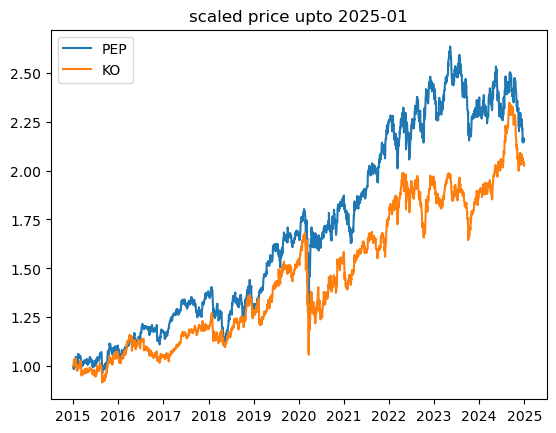

In [4]:
plt.plot(data['PEP']/data['PEP'].iloc[0],label='PEP')
plt.plot( data['KO']/data['KO'].iloc[0],label='KO')
plt.legend()
plt.title('scaled price upto 2025-01')
plt.show()

In [6]:
data_2023 = data[data.index <= '2023-01-01'].copy()

In [7]:
score , p_value,_  = coint(data_2023['PEP'],data_2023['KO'])
print(f'for data to 2023, score is {score}, p_value is  {p_value}')

for data to 2023, score is -3.8285065328982646, p_value is  0.012414732532337462


For the data before 2023 it appears cointgration(p-value<0.05), but for the data 2025, it doesn't.

### Least square approach
Use least square to estimate $\beta$. Our training set is the data upto 2023/1/1 and testing set is the rest.

In [5]:
def ls(df,pair:list,separation_time,log=False): 
    df_train = df[df.index<=separation_time]
    if log:
        p1 = np.log(df_train[pair[0]].values)
        p2 = np.log(df_train[pair[1]].values)
    else:
        p1 = df_train[pair[0]].values
        p2 = df_train[pair[1]].values
    X = sm.add_constant(p2)
    result = sm.OLS(p1,X).fit()
    beta = result.params[1]
    return beta

From least square we get the estimated linear combination coefficient $\beta =  0.29752124$

[Augmented Dickey–Fuller test](https://en.wikipedia.org/wiki/Augmented_Dickey%E2%80%93Fuller_test) shows the weak stationarity of spread is indeed statistically significant.

In [ ]:

adf_test = adfuller(spread)
print(f'p-value is {adf_test[1]}')

### Kalman filter approach
[ref 1](https://web.mit.edu/kirtley/kirtley/binlustuff/literature/control/Kalman%20filter.pdf) , [ref 2](https://palomar.home.ece.ust.hk/MAFS5310_lectures/slides_pairs_trading.pdf) and 
[ref 3](https://bookdown.org/palomar/portfoliooptimizationbook/15.6-kalman-pairs-trading.html)

We can also consider time-varying parameters
$$
p_1(t) = \beta_t p_2(t) + \mu_t + \varepsilon_t
$$
and $\varepsilon_t$ is again weak stationary. So the mean-reversion band is now time-varying: $[ \mu_t - \alpha \sigma_\varepsilon , \mu_t + \alpha \sigma_\varepsilon]$, where $\alpha$ is the hyperparameter determining the width of band.

To estimate $\mu_t$ and $\beta_t$, we will use Kalman filter, which is a common method to estimate the state variables 
$\{\mathbf{x}_t\}_{t \geq 0}$ of a system which are unkown for us using obersvation $\{\mathbf{y}_t\}_{t \geq 0}$ and covariance matrices $Q$, $R$ of system noises $\{\mathbf{w}_t\}_{t \geq 0}$, $\{\mathbf{v}_t\}_{t \geq 0}$.
Their relations are given by:
* system dynamics: 

    $x_{t+1} = \Phi x_t + w_t$, where $\Phi$ is the given transition matrix and $w_t \sim N(0,Q)$

* model for observation:

    $y_t = H x_t + v_t$, where $H$ is another given matrix characterize the connection between $\mathbf{x}$, $\mathbf{y}$  and $v_t \sim N(0,R)$
    

The main idea is to iterlatively perform two steps estimation on $\mathbf{x}$: prior estimation $\hat{\mathbf{x}}$ by dynamics, posterior estimation $\hat{\mathbf{x}}'$ by observation and minimizing mean-square error(MSE). More precisely, for $t>0$, we have:

$$
\hat{\mathbf{x}}'_t = \Phi \hat{\mathbf{x}}_{t-1} \; , \; 
\hat{\mathbf{x}}_t =  \hat{\mathbf{x}}'_t +  K_t(\mathbf{y}-H\hat{\mathbf{x}}_t )
$$
Here $K_t= $ is called Kalman gain matrix. It is derived by minimizing MSE
. We give the explict forumla later.
Let the error matrix:
$$
P_t \equiv \mathbb{E}( (\mathbf{x}_t-\hat{\mathbf{x}}_t)(\mathbf{x}_t-\hat{\mathbf{x}}_t)^T )
$$
Replace $\hat{\mathbf{x}}_t$ in $P_t$ by the estimation formula in terms of $\hat{\mathbf{x}}'_t$, we have
$$
P_t = (I-K_t H)P'_t
$$
where $P'_{t+1}\equiv \mathbb{E}( (\mathbf{x}_{t+1}-\hat{\mathbf{x}}'_{t+1})(\mathbf{x}_{t+1}-\hat{\mathbf{x}}'_{t+1})^T )= \Phi P_t \Phi^T + Q$ is the priori estimate covariance.
The kalman gain matrix $K_t$ is chosen to minimize the trace of error matrix
(i.e MSE) among all choices. Solving some matrices calculus one derives
$$
K_t =  P'_t H^T (H P'_t H^T +R)^{-1}
$$

In our case, we would like to use Kalman filter to find time varing parameters
$\mu_t$ and $\beta_t$. We set

* $\mathbf{x}_t = (\mu_t , \beta_t)^T$

* $\Phi = \mathbb{1}_{2 \times 2}$

* $H = ( 1, p_2(t))$

* $Q =  \begin{pmatrix}
 \sigma_1^2& 0 \\
0 & \sigma_2^2 \end{pmatrix} $

* $R = \sigma_3^2$

We will use the package [pykalman](https://github.com/pykalman/pykalman/tree/main). (For the hyperparameters $Q$, $R$, initial estimated states $(\hat{\mu}_0 ,\hat{\beta}_0  )$ and error matrix $P_0$, we manually asign $(\hat{\mu}_0 ,\hat{\beta}_0 ,Q,R,P_0 )= (\mu_{ls},\beta_{ls},\begin{pmatrix} \frac{\alpha \cdot \sigma_{ls}}{\sigma} & 0 \\0 &  \alpha \cdot \sigma_{ls} \end{pmatrix} , \sigma_{ls},  10\cdot\mathbb{1}_{2 \times 2})$ where $\alpha$ is a hyperparameter which we set to $10^{-5}$,
$\beta_{ls}, \sigma_{ls}, \mu_{ls}$ are least-square beta, spread std and mean, $\sigma$ is the training price std. We also try to use EM algorithm provided by pkalman to optimize these initial parameters.

**Functions**

``` kf```: Generate $\mu_t$ and $\beta_t$ by Kalman filter.

**Parameters**
* ``` df ```: pandas dataframe, the input data.

* ```pair```: list of two strings corresponding to asset names in df

* ```separate_time```:  Date to separate the EM algorithm training for initial parameters
  from testing. If you don't want to separate test and train, just set the date exceeding the last date of the data.

* ``` n_em ```:　Number of EM training iterations.

* ```em```: If true, run EM algorithm for optimize initial parameters.

In [20]:
def kf(df, pair: list,separation_time,
       n_em=20,em=True,log=False):
    # training set
    df_train = df[df.index<=separation_time].copy()
    if log:
        price_1_train = np.log(df_train[pair[0]].values)
        price_2_train = np.log(df_train[pair[1]].values)
    else:
        price_1_train = df_train[pair[0]].values
        price_2_train = df_train[pair[1]].values
    
    # traing using em
    n = len(price_2_train)
    obs_mat_train=np.stack([price_2_train, np.ones(n)], axis=1)[:, np.newaxis]

    kf_train=KalmanFilter(
        transition_matrices=np.eye(2),
    observation_matrices=obs_mat_train,
    initial_state_mean=ini_mean,
    initial_state_covariance=ini_cov ,
    transition_covariance=tran_cov ,
    observation_covariance=obs_cov)
    if em :
        kf_train = kf_train.em(price_1_train , n_iter = n_em)

    train_mean, train_cov = kf_train.filter(price_1_train)
    
    # if we don't want to separate test and train
    if df.index[-1]<= separation_time:
        return train_mean[:,1] , train_mean[:,0]
    
    # testing using parameters from trainging
    
    # testing set
    df_test = df[df.index>separation_time].copy()
    if log:
        price_1_test = np.log(df_train[pair[0]].values)
        price_2_test = np.log(df_train[pair[1]].values)
    else:
        price_1_test = df_test[pair[0]].values
        price_2_test = df_test[pair[1]].values
    
    ini_test_mean =( train_mean[:,0][-1],train_mean[:,1][-1])
    #kf_train.initial_state_mean
    m= len(price_2_test)
    obs_mat_test=np.stack([price_2_test, np.ones(m)], axis=1)[:, np.newaxis]  
    kf_test = KalmanFilter(
        transition_matrices=np.eye(2),
        observation_matrices=obs_mat_test,
        transition_covariance=kf_train.transition_covariance,
        observation_covariance=kf_train.observation_covariance,
        initial_state_mean= ini_test_mean,
        initial_state_covariance= train_cov[-1])

    test_mean, _ = kf_test.filter(price_1_test)
    # combine train and test result
    mean, beta =(np.concatenate([train_mean[:,1],test_mean[:,1]]),
                 np.concatenate([train_mean[:,0],test_mean[:,0]]))
    return mean,beta

### Construct long/short strategy and backtest
First we can try $\mu \pm \sigma$ as upper(U) and lower(L) thresh hold

The idea of trading strategy is that:

* Each time the spread crosses the mean value from outside the band, we liquidate the spread position.
* The first time the spread crosses the upper level from inside the band after leaving mean value, we long one unit of KO and short $\beta$ unit of PEP.
* The first time the spread crosses the lower level from inside the band after leaving mean value, we short one unit of KO and long $\beta$ unit of PEP.

Here since we consider the price difference as the spread, each time we trade constant shares in long and short position. Some may consdier the linear combination of log prices
of the two assets. Then it correspond to constant weight portifolio where the weight ratio
is $(1,\beta)$.
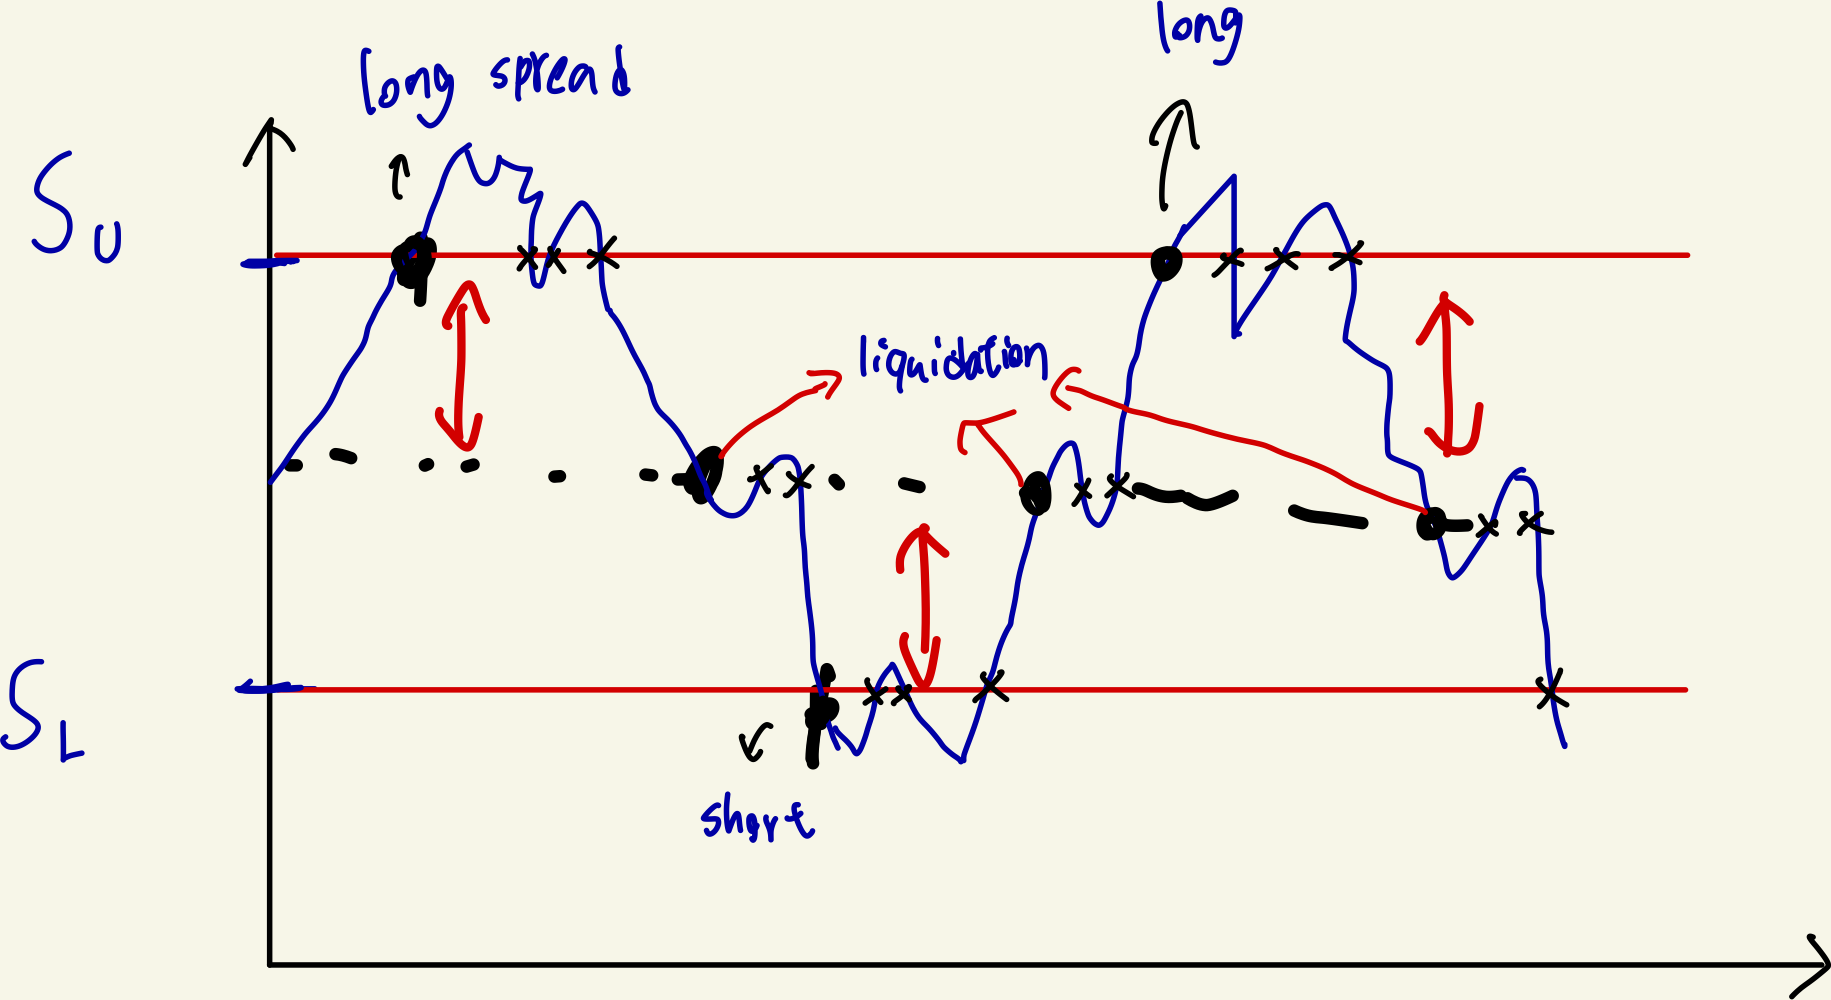

We can also formulate these trading timing following this [paper](https://arxiv.org/abs/2011.02870). Let $\tau^-_0= \theta^-_i=\tau^+_0= \theta^+_i=0$
and 

\begin{align*}
\forall i\geq 1,\quad &\tau^+_i=\inf\{ t>\theta^+_{i-1}\mid S(t)\geq S_U \} \quad 
\theta^+_i=\inf\{ t>\tau_{i}^+ \mid  S(t)\leq \mu \} 
\\\\
&\tau^-_i=\inf\{ t>\theta^-_{i-1} \mid S(t)\leq S_L \} \quad \theta^-_i=\inf\{ t>\tau^-_{i}\mid S(t)\geq \mu \} 
\end{align*}

In our setting, $S_U = \mu + \sigma$ and $S_L = \mu - \sigma$. 

 Since we are not self-financed, we also consider a cash position. The initial
wealth is net zero. We compute the cumulative strategy PnL at time $t$ as
$$
CumPnL(t) = 
\text{cash at time t} \; + \; \text{pair position value} \; - \; \text{initial capital} = \text{cash at time t} \; + \; \tilde{S}(t)
$$

where $\tilde{S}(t) = sig(t) S(t)$ and $sig(t)$ is the signal at time $t$.


We add two limitation options for risk management. One is the stop loss level. If the traded spread deviates from traaded $\mu$ too much($\pm \cdot $ stop level $\cdot$ std ),liquidate it and trade until spread goes back to the band. Another is the waiting time constraint. If holding the position too long, liquidate it. It happens sometimes that spread doesn't deviate traded $\mu$ to much nor goes back to the traded $\mu$. 

Also note that for time-varing $\mu$, and $\beta$, here we fix the parameters when open a position(i.e buy and hold) and  liquidate the position when the spread is back to this fixed $\mu$.

### Simple pair trading

***Functions***

```pair_trading```: Compute the spread, signal, cumlative PnL, etc from the input $\mu$  
                    ,$\beta$ and price data. 

***Parameters***
* ```separation_time``` The data before separation time will be used to compute spread  
                         standard deviation $\sigma$. 
* ```width```: The width of the mean-reversion band. The upper/lower levels are $\pm width                \cdot \sigma$.
* ```a_trad```: The trading fee rate.

* ```a_short```: The short fee rate.

* ``` stop_level ```:  The stop loss level, the upper/lower stop loss levels are $\pm 
                    stop\_level \cdot \sigma$.
            
* ```T_holding``` : The holding time constraint. 
                   
* ```plot```: Plot the spread, signal and cumulative PnL if ```True```.

In [21]:

def pair_trading(mu,beta,df,pair: list,separation_time,width=1,a_trade=0.0003,
                 a_short=0.0003,T_holding= None,stop_level=None, plot = False):
    
    # if mu or beta is scalars, turn then into aconstant sequences
    if isinstance(mu, (int, float, complex)):
        mu = mu*np.ones(len(df))
    if isinstance(beta, (int, float, complex) ):
        beta = beta*np.ones(len(df))
    price_1 = df[pair[0]].values
    price_2 = df[pair[1]].values

    spread = price_1 - beta*price_2
    # values before start, set to be zeros
    # spread = np.insert(spread,0,0)
    
    # to avoid look-ahead, upper/lower level use std from training set
    N= len(df[df.index<=separation_time])
    std= np.std( spread[:N]-mu[:N] ) 
    U=width*std
    L=-width*std
    if stop_level!= None:
        U_loss = stop_level*std
        L_loss = -stop_level*std

    
    
    signal = np.zeros_like(spread)
    liquidation= np.zeros_like(spread)
    cash = np.zeros_like(spread)
    position_value =np.zeros_like(spread)
    cumPnL = np.zeros_like(spread)
    
    # initial trading time setting
    t_change=1
    
    # jump when there's trade, to plot the jumping time serires, we define a new data frame  
    df_plot = pd.DataFrame(columns=['date','mu','beta','signal','spread']) 
    
    # traded mu and beta
    mu_trade = mu.copy()
    beta_trade = beta.copy()
    
    
    #record the holding time
    t_holding= 0
    status = 'active'
    for t in range(1,len(spread)):
        # if stop loss limitation is triggered
        if status == 'loss_stop':
            signal[t]=0
            if (spread[t]>mu_trade[t] + L) and (spread[t]<mu_trade[t] + U):
                status = 'active'

        if status =='active':
            # none at t-1
            if  signal[t-1] ==0:
                if  spread[t] <mu[t] + L:
                    signal[t]= 1
                    t_holding=1

                elif spread[t]>mu[t] +U:
                    signal[t]=-1
                    t_holding=1

                else:
                    signal[t] =0
                    
            # has position at t-1
            else:
                # still haven't changed signal, mu and beta are fixed
                mu_trade[t] = mu_trade[t-1]
                beta_trade[t] = beta_trade[t-1]
                
                # current traded spread using beta at entry time
                spread[t]=price_1[t] - beta_trade[t]*price_2[t]

                # holding time limitation
                if T_holding != None:
                    if t_holding > T_holding:
                        status = 'holding_stop'
                        # current traded spread using beta at entry time
                        signal[t] = 0
                        t_holding = 0

                #spread deviaion limit, higher priority
                if stop_level != None:
                    if (spread[t] >= mu_trade[t] + U_loss) or (spread[t] <= mu_trade[t] + L_loss):
                        status = 'loss_stop'
                        signal[t]= 0 
                        t_holding = 0
                        
                # if limitatioion still isn't triggered        
                if status =='active':
                    # long at t-1
                    if  signal[t-1] ==1:

                        if  spread[t] < mu_trade[t]:
                            signal[t]= 1
                            t_holding+=1

                        elif spread[t]>mu_trade[t]+U:
                            signal[t]=-1
                            t_holding=1

                        else:
                            signal[t] =0
                            t_holding=0

                    # short at t-1
                    else:
                        if  spread[t] > mu_trade[t]: 
                            signal[t]= -1
                            t_holding+=1

                        elif spread[t]< mu_trade[t]+L:
                            signal[t]=1
                            t_holding=1

                        else:
                            signal[t] =0
                            t_holding=0
        # df_plot setting
        date = df.index[t]
        
        if signal[t-1] != signal[t]:
            
            # record the profit when liquidation
            liquidation[t] = signal[t-1]*spread[t]

            
            # values at time t but before trade if there is 
            df_plot.loc[len(df_plot),['date','mu','beta','U','L','signal',
                                      'spread'] ] =[date,mu_trade[t],beta_trade[t],U,
                                                    L,signal[t-1],spread[t]]
            
            # update mu and beta correspond to new spread
            mu_trade[t] = mu[t]
            beta_trade[t] = beta[t]
            
            # spread of the new position(may be an empty position if signal=0)
            spread[t] = price_1[t] - beta_trade[t]*price_2[t]
         
            position_value[t] = signal[t]*spread[t]
            
            # trading fee = liquidation + new position
            fee_trade = a_trade * (np.abs(liquidation[t])+np.abs(price_1[t]) +beta_trade[t]*np.abs(price_2[t]))
            change = liquidation[t] - position_value[t] - fee_trade
        #if no trade, update position value
        else:
            position_value[t] = signal[t]*spread[t]
            change = 0

    

        # values at time t but after trade
        df_plot.loc[len(df_plot),['date','mu','beta','signal'
                                  ,'spread'] ] =[date,mu_trade[t], beta_trade[t],
                                                 signal[t],spread[t]]
        
        # holding cost from short
        if signal[t] == -1:
            fee_short = a_short * beta[t]*price_2[t]
        else:
            fee_short = 0
        #cash and PnL update
        cash[t] = cash[t-1]  + change - fee_short
        cumPnL[t] =  cash[t] + position_value[t]
        
        
        # if holding time limitation is on, reactivate at the end of each period
        if  status == 'holding_stop':
            status = 'active'

        

    df.loc[:,'traded spread'] = spread
    df.loc[:,'signal'] = signal
    df.loc[:,'liquidation'] = liquidation
    df.loc[:,'cash'] = cash
    df.loc[:,'cumPnL']= cumPnL
    df.loc[:,'position_value']=position_value
    
    if plot:
        fig,ax = plt.subplots(3,1,sharex=True,figsize=(12,12))
        ax[0].plot(df_plot['date'],df_plot['spread']-df_plot['mu'],c='k')
        ax[0].axhline(y=L,c='dodgerblue',ls='dashdot')
        ax[0].axhline(y=U,c='dodgerblue',ls='dashdot')

        ax[0].set_ylabel('spread',fontsize=15)

        ax[1].plot(df_plot['date'],df_plot['signal'],c='k')
        ax[1].set_ylabel('signal',fontsize=15)

        ax[2].plot(df.index,df['cumPnL'],c='k') 
        ax[2].set_ylabel('cumPnL',fontsize=15)
        for i in range(3):
            ax[i].grid()
            ax[i].axvline(x= datetime(2023,1,1),c='r',ls='--')
        plt.show()
    return df,mu,U,L

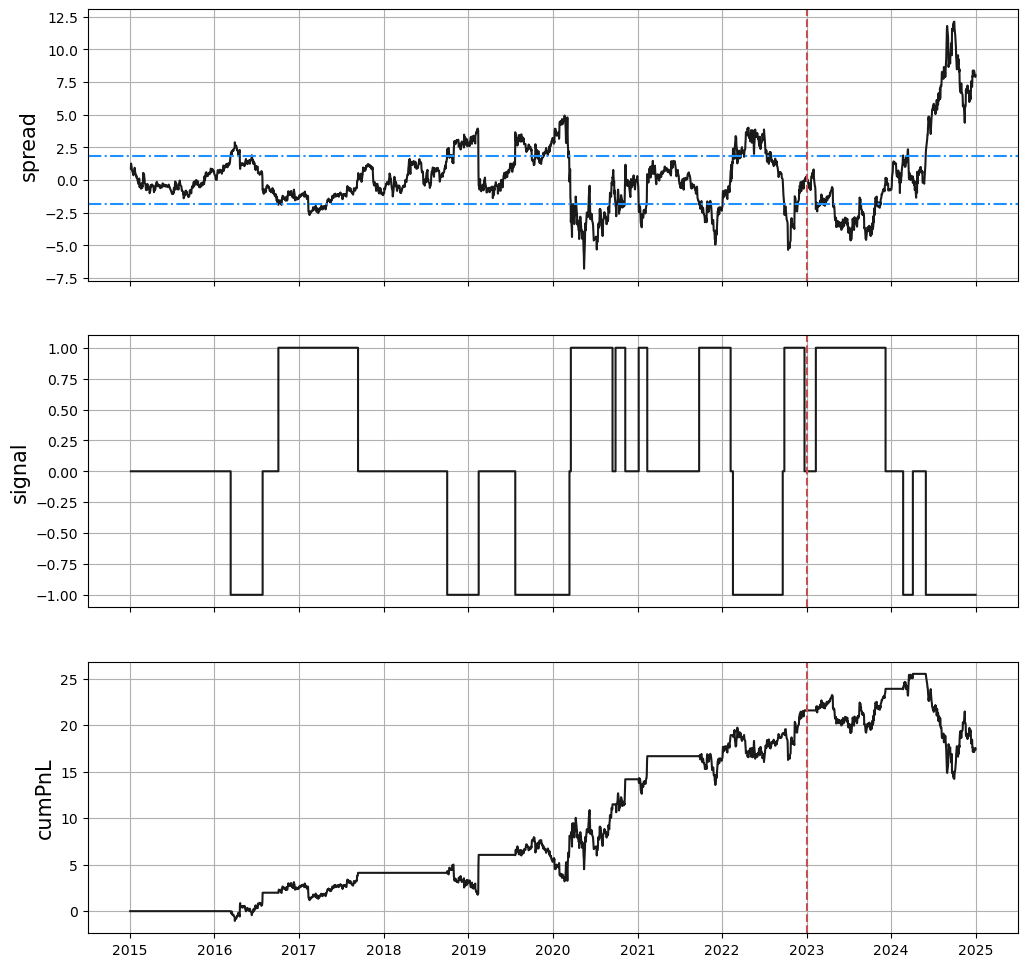

In [22]:
df_ls = data.copy()
beta = ls(df_ls,['KO','PEP'],datetime(2023,1,1))
mu = np.mean( df_ls[df_ls.index<=datetime(2023,1,1)]['KO'] - 
             beta*df_ls[df_ls.index<=datetime(2023,1,1)]['PEP']  )
df_ls,mu,U,L = pair_trading(mu,beta,df_ls,['KO','PEP'],
                          separation_time=datetime(2023,1,1),width=1,plot=True)

In [23]:
# Kalman filter parameters setting
b=ls(df_ls,['KO','PEP'],datetime(2023,1,1))
ls_mean = df_ls[df_ls.index<= '2023-1-1']['traded spread'].mean()
ls_std=np.std(df_ls[df_ls.index<= '2023-1-1']['traded spread'] - 
                ls_mean)
std_2 = df_ls[df_ls.index<= '2023-1-1']['PEP'].std()

ini_mean=(b, ls_mean ) 
inicov=1e1
ini_cov=inicov * np.eye(2)
alpha=10**-5
tran_cov=np.array([ [alpha*ls_std/std_2,0],
    [ alpha*ls_std,0]
                    ])
obs_cov=ls_std 



Text(0.5, 1.0, 'w/o em, stop level= $\\pm $ 12 std, holding 150 tading days')

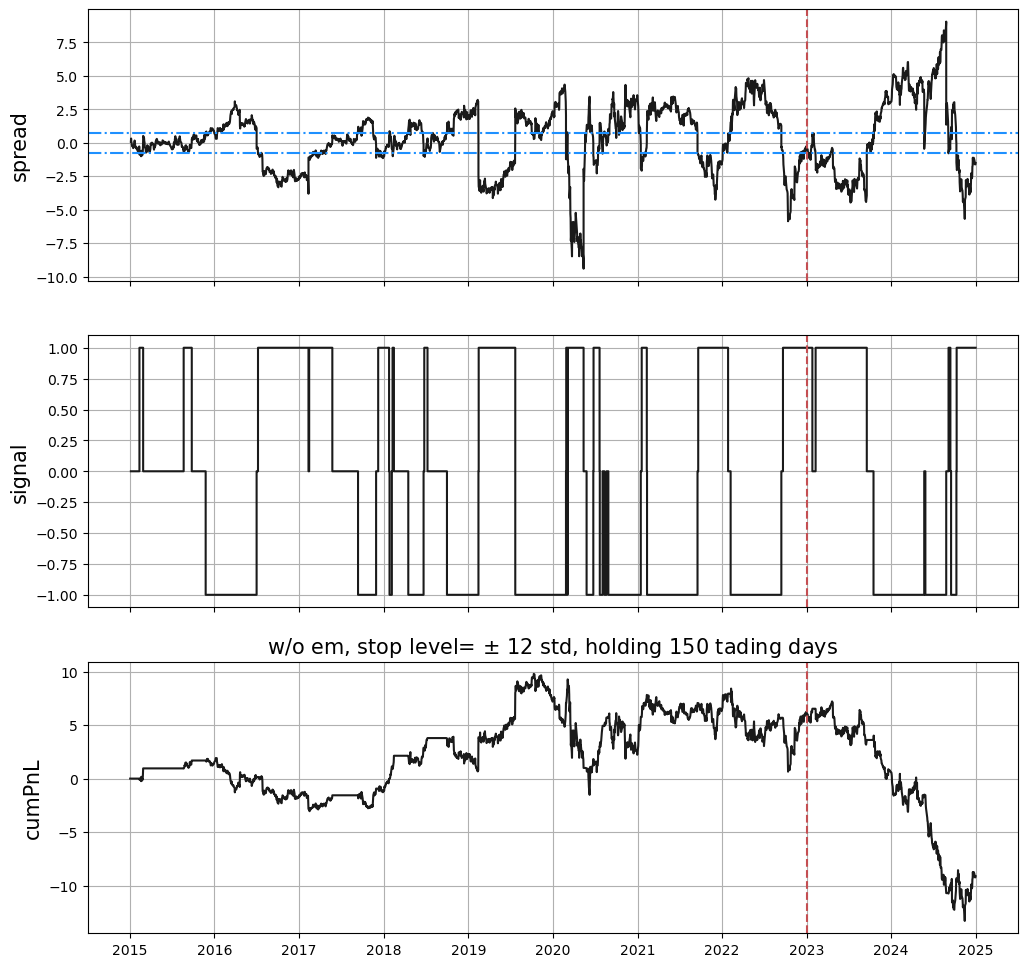

In [19]:
df_kf_noem= data.copy()
mu,beta = kf(df_kf_noem,['KO','PEP'],separation_time=datetime(2026,1,1),em=False)
df_kf_noem,mu,U,L = pair_trading(mu,beta,df_kf_noem,['KO','PEP'],
                          separation_time=datetime(2023,1,1),width=1,T_holding= 150,
                                 stop_level=12,plot=True)
plt.title(r'w/o em, stop level= $\pm $ 12 std, holding 150 tading days',fontsize=15)

In [ ]:
df_kf_noem= data.copy()
mu,beta = kf(df_kf_noem,['KO','PEP'],separation_time=datetime(2023,1,1),em=False)
df_kf_noem,mu,U,L = pair_trading(mu,beta,df_kf_noem,['KO','PEP'],
                          separation_time=datetime(2023,1,1),width=1,plot=True)
plt.title(r'w/o em and risk management',fontsize=15)

Text(0.5, 1.0, 'em on, stop level= $\\pm $ 20 std, holding 150 tading days')

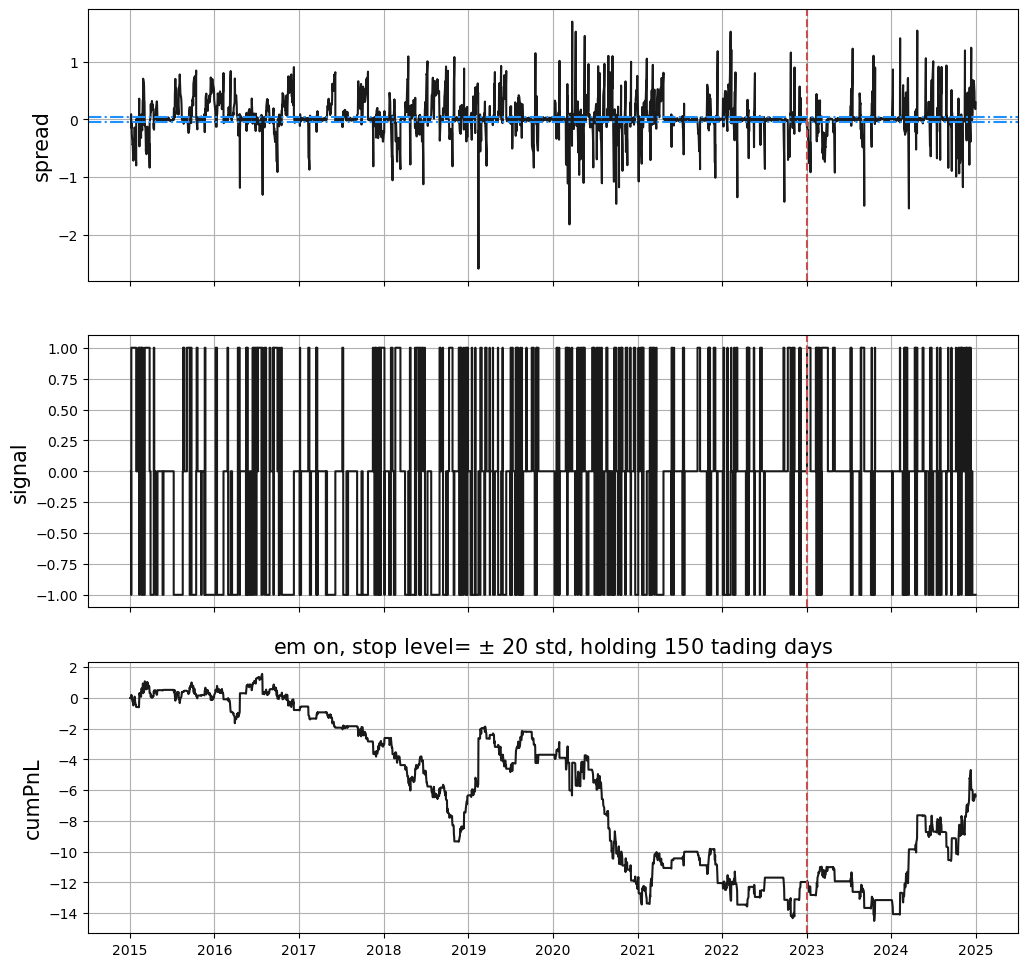

In [21]:
df_kf= data.copy()
mu,beta = kf(df_kf,['KO','PEP'],separation_time=datetime(2023,1,1))
df_kf,mu,U,L = pair_trading(mu,beta,df_kf,['KO','PEP'],
                          separation_time=datetime(2023,1,1),width=1,T_holding=150, stop_level=20,plot=True)
plt.title(r'em on, stop level= $\pm $ 20 std, holding 150 tading days',fontsize=15)

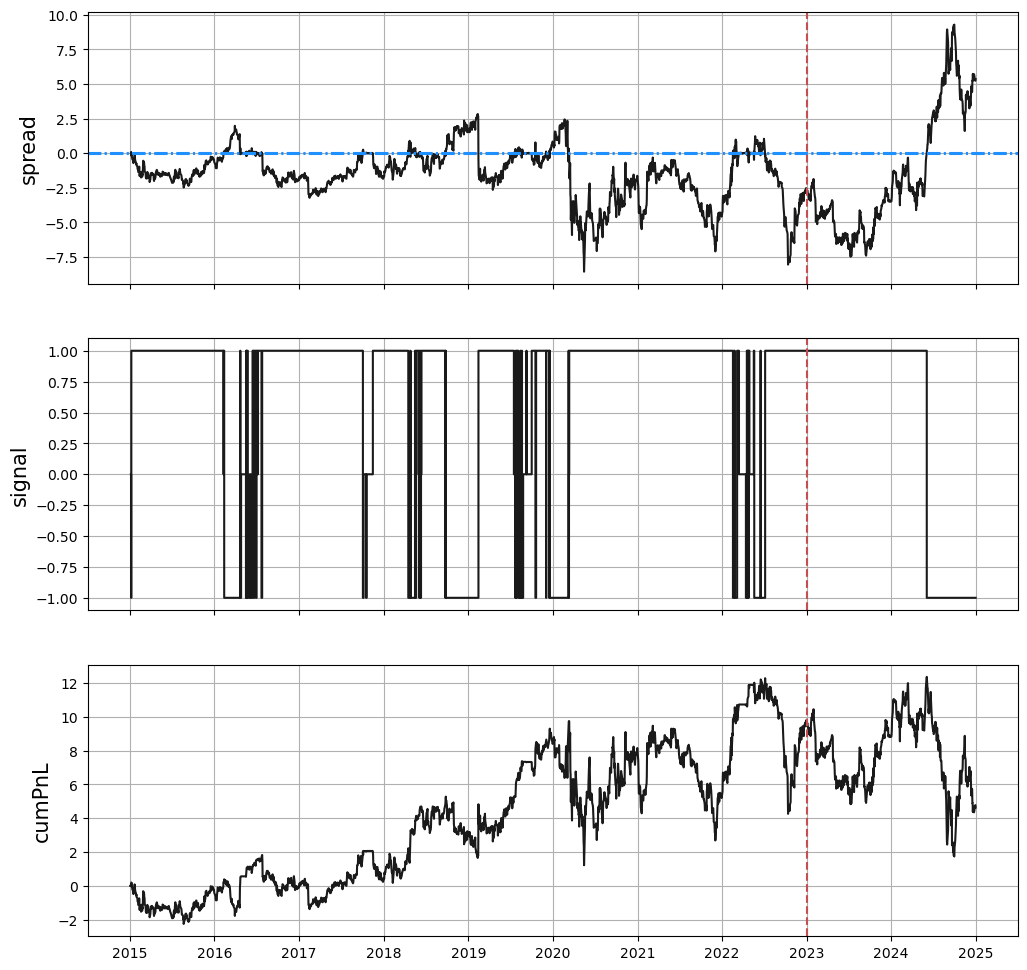

In [17]:
df_kf= data.copy()
mu,beta = kf(df_kf,['KO','PEP'],separation_time=datetime(2023,1,1))
df_kf,mu,U,L = pair_trading(mu,beta,df_kf,['KO','PEP'],
                          separation_time=datetime(2023,1,1),width=1,plot=True)
plt.title(r'em on, w/o risk management',fontsize=15)

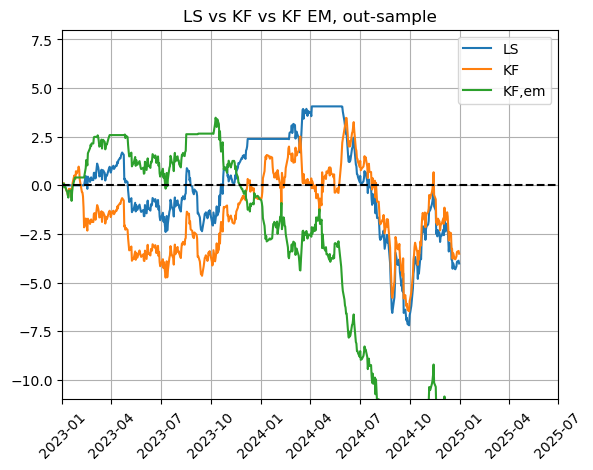

In [200]:
plt.plot(df_ls.index,df_ls['cumPnL']-
         df_ls[df_ls.index>=datetime(2023,1,1)]['cumPnL'].iloc[0],label='LS') 

plt.plot(df_kf_noem.index,df_kf_noem['cumPnL']-
         df_kf_noem[df_kf_noem.index>=datetime(2023,1,1)]['cumPnL'].iloc[0],
         label='KF') 
plt.plot(df_kf.index,df_kf['cumPnL']-
         df_kf[df_kf.index>=datetime(2023,1,1)]['cumPnL'].iloc[0],
         label='KF,em') 
plt.axhline(y=0,ls='--',c='k')
plt.xlim(datetime(2023,1,1))
plt.ylim(-11,8)
plt.xticks(rotation=45);
plt.legend()
plt.grid()
plt.title('LS vs KF vs KF EM, out-sample');

### Rolling 
In this part we consider rolling OLS and rolling standard deviation of spread minus $\mu$ (for updating upper/lower levels). We use the standard deviation for leveling given  by the following:

$$
\sigma_t = \begin{cases}
\frac{1}{\Delta}\displaystyle\sum_{s= t- \Delta}^{t-1} (S(s) - \mu(s))^2 & \text{if} \; t \geq 2 \Delta \\
\frac{1}{\Delta}\displaystyle\sum_{s= t- \Delta}^{t-1} (S_{trade}(s) - \mu_{trade}(s))^2 & \text{if} \;   \Delta \geq t \leq 2 \Delta -1 \\
\end{cases}
$$
where $\Delta$ is the rolling window, $S_{trade}(t)$ and $\mu_{trade}(t)$ are
the exact object we trade.

***Functions***

```ls_rolling```: Compute $\beta$ and $\mu$ by rolling OLS.

```pair_trading_rolling```: Compute the spread, signal, cumlative PnL, etc from the input $\mu$ ,$\beta$ and price data. Here the standard deviation is also aomputed by rolling( hence the upper/lower levels).

***Parameters***
* ```rolling_windows```: The rolling windows in days.

In [29]:

def ls_rolling(df,pair,rolling_window =10 ):
    y = df[pair[0]]
    x = df[pair[1]]
    beta_rolling = []

    for t in range(rolling_window, len(df)+1):
        y_window = y.iloc[t - rolling_window+1:t+1].copy()
        x_window = x.iloc[t - rolling_window+1:t+1].copy()
        X = sm.add_constant(x_window)
        result = sm.OLS(y_window, X).fit()
        beta_rolling.append(result.params.iloc[1])
    spread = list(y.values[rolling_window-1:] - beta_rolling*x.values[rolling_window-1:])   
    spread = list(y.values[:rolling_window-1] - beta_rolling[0]*x.values[:rolling_window-1]) + spread 
    mu = pd.Series(spread).rolling(window=rolling_window ).mean().values
    return beta_rolling, mu[rolling_window-1:] 

def pair_trading_rolling(mu,beta,df,pair: list,width=1,
                         a_trade=0.003,a_short=0.003,T_holding= None,
                         stop_level=None, rolling_window = 10 ,plot = False):
    df = df.iloc[rolling_window-1:].copy()
    price_1 = df[pair[0]].values
    price_2 = df[pair[1]].values
    
    spread = price_1 - beta*price_2
    
    # QQ = spread.copy()  this is for checking , can be ignored
    
    std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
    U=width*std_roll
    L=-width*std_roll
    if stop_level!= None:
        U_loss = stop_level*std_roll
        L_loss = -stop_level*std_roll  
    
    signal = np.zeros_like(spread)
    liquidation= np.zeros_like(spread)
    cash = np.zeros_like(spread)
    position_value =np.zeros_like(spread)
    cumPnL = np.zeros_like(spread)
    
 
    # traded mu and beta
    mu_trade = mu.copy()
    beta_trade = beta.copy()
    
    # jump when there's trade, to plot the jumping time serires, we define a new data frame  
    df_plot = pd.DataFrame(columns=['date','mu','beta','U','L','signal','spread']) 
    
    #record the holding time
    t_holding= 0
    status = 'active'
    for t in range(1,len(spread)):
        # set rolling of traded spread and corresponding levels
        if t >= rolling_window:
            # use data before t to compute rolling std
            std_roll[t] = np.std(spread[ t-rolling_window: t])
            U[t]=width*std_roll[t]
            L[t]=-width*std_roll[t]
            if stop_level!= None:
                U_loss[t] = stop_level*std_roll[t]
                L_loss[t] = -stop_level*std_roll[t] 
        # if stop loss limitation is triggered
        if status == 'loss_stop':
            signal[t]=0
            if (spread[t]>mu_trade[t] + L[t]) and (spread[t]<mu_trade[t] + U[t]):
                status = 'active'

        if status =='active':
            # none at t-1
            if  signal[t-1] ==0:
                if  spread[t] <mu[t] + L[t]:
                    signal[t]= 1
                    t_holding=1

                elif spread[t]>mu[t] +U[t]:
                    signal[t]=-1
                    t_holding=1

                else:
                    signal[t] =0
                    
            # has position at t-1
            else:
                # still haven't changed signal, mu and beta are fixed
                mu_trade[t] = mu_trade[t-1]
                beta_trade[t] = beta_trade[t-1]
                
                # current traded spread using beta at entry time
                spread[t]=price_1[t] - beta_trade[t]*price_2[t]

                # holding time limitation
                if T_holding != None:
                    if t_holding > T_holding:
                        status = 'holding_stop'
                        # current traded spread using beta at entry time
                        signal[t] = 0
                        t_holding = 0

                #spread deviaion limit, higher priority
                if stop_level != None:
                    if (spread[t] >= mu_trade[t] + U_loss[t]) or (spread[t] <= mu_trade[t] + L_loss[t]):
                        status = 'loss_stop'
                        signal[t]= 0 
                        t_holding = 0
                        
                # if limitatioion still isn't triggered        
                if status =='active':
                    # long at t-1
                    if  signal[t-1] ==1:

                        if  spread[t] < mu_trade[t]:
                            signal[t]= 1
                            t_holding+=1

                        elif spread[t]>mu_trade[t]+U[t]:
                            signal[t]=-1
                            t_holding=1

                        else:
                            signal[t] =0
                            t_holding=0

                    # short at t-1
                    else:
                        if  spread[t] > mu_trade[t]: 
                            signal[t]= -1
                            t_holding+=1

                        elif spread[t]< mu_trade[t]+L[t]:
                            signal[t]=1
                            t_holding=1

                        else:
                            signal[t] =0
                            t_holding=0
        # df_plot setting
        date = df.index[t]
        
        if signal[t-1] != signal[t]:
            
            # record the profit when liquidation
            liquidation[t] = signal[t-1]*spread[t]

 
            
            # values at time t but before trade if there is 
            df_plot.loc[len(df_plot),['date','mu','beta','U','L','signal',
                                      'spread'] ] =[date,mu_trade[t],beta_trade[t],U[t],
                                                    L[t],signal[t-1],spread[t]]
            
            # update mu and beta correspond to new spread
            mu_trade[t] = mu[t]
            beta_trade[t] = beta[t]
            
            # spread of the new position(may be an empty position if signal=0)
            spread[t] = price_1[t] - beta_trade[t]*price_2[t]
         
            position_value[t] = signal[t]*spread[t]

            fee_trade = a_trade * (np.abs(liquidation[t]) +np.abs(price_1[t])) +beta_trade[t]*np.abs(price_2[t])
            
            change = liquidation[t] - position_value[t] - fee_trade
        #if no trade, update position value
        else:
            position_value[t] = signal[t]*spread[t]
            change = 0

        
        
       
        
        # values at time t but after trade
        df_plot.loc[len(df_plot),['date','mu','beta','U','L','signal'
                                  ,'spread'] ] =[date,mu_trade[t], beta_trade[t],
                                                 U[t],L[t],signal[t],spread[t]]
        
        # holding cost from short
        if signal[t] == -1:
            fee_short = a_short * beta[t]*price_2[t]
        else:
            fee_short = 0
        #cash and PnL update
        cash[t] = cash[t-1]  + change - fee_short
        cumPnL[t] =  cash[t] + position_value[t]
        
        
        # if holding time limitation is on, reactivate at the end of each period
        if  status == 'holding_stop':
            status = 'active'

        

    df.loc[:,'traded spread'] = spread
    df.loc[:,'signal'] = signal
    df.loc[:,'liquidation'] = liquidation
    df.loc[:,'cash'] = cash
    df.loc[:,'cumPnL']= cumPnL
    df.loc[:,'position_value']=position_value
    
    if plot:
        fig,ax = plt.subplots(3,1,sharex=True,figsize=(12,12))
        ax[0].plot(df_plot['date'],df_plot['spread'],c='k')
        ax[0].plot(df_plot['date'],df_plot['mu'])
        ax[0].plot(df_plot['date'],df_plot['L']+df_plot['mu'].values,c='dodgerblue',ls='dashdot')
        ax[0].plot(df_plot['date'],df_plot['U']+df_plot['mu'].values,c='dodgerblue',ls='dashdot')

        ax[0].set_ylabel('spread',fontsize=15)

        ax[1].plot(df_plot['date'],df_plot['signal'],c='k')
        ax[1].set_ylabel('signal',fontsize=15)

        ax[2].plot(df.index,df['cumPnL'],c='k') 
        ax[2].set_ylabel('cumPnL',fontsize=15)
        for i in range(3):
            ax[i].grid()
        plt.show()
    return df,mu,U,L


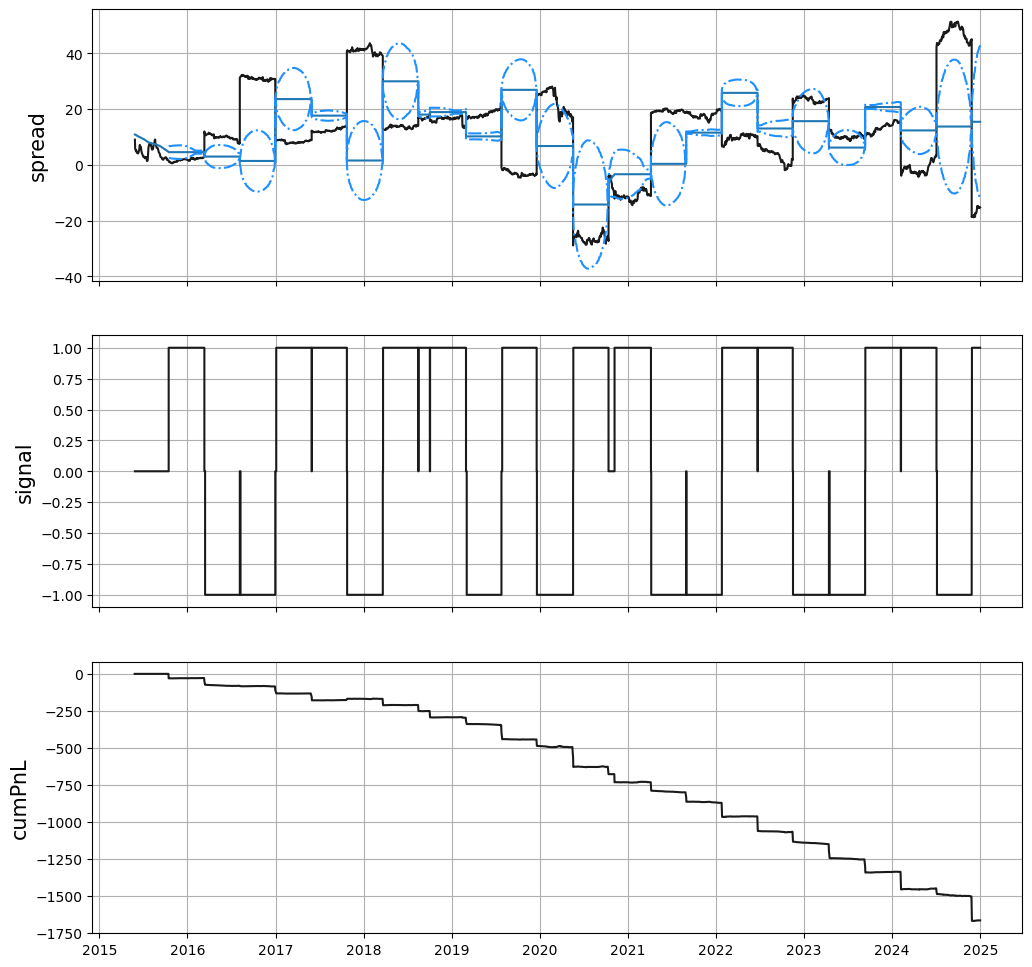

In [23]:
df_lsr = data.copy()
rolling_window = 100
beta ,mu = ls_rolling(df_lsr,['KO','PEP'],rolling_window =rolling_window )
df_lsr,mu,U,L = pair_trading_rolling(mu,beta,df_lsr,pair=['KO','PEP'],width=1,
                                    T_holding=100,rolling_window = rolling_window
                                    ,stop_level=None,plot=True)




Text(0.5, 1.0, 'w/o em, risk management')

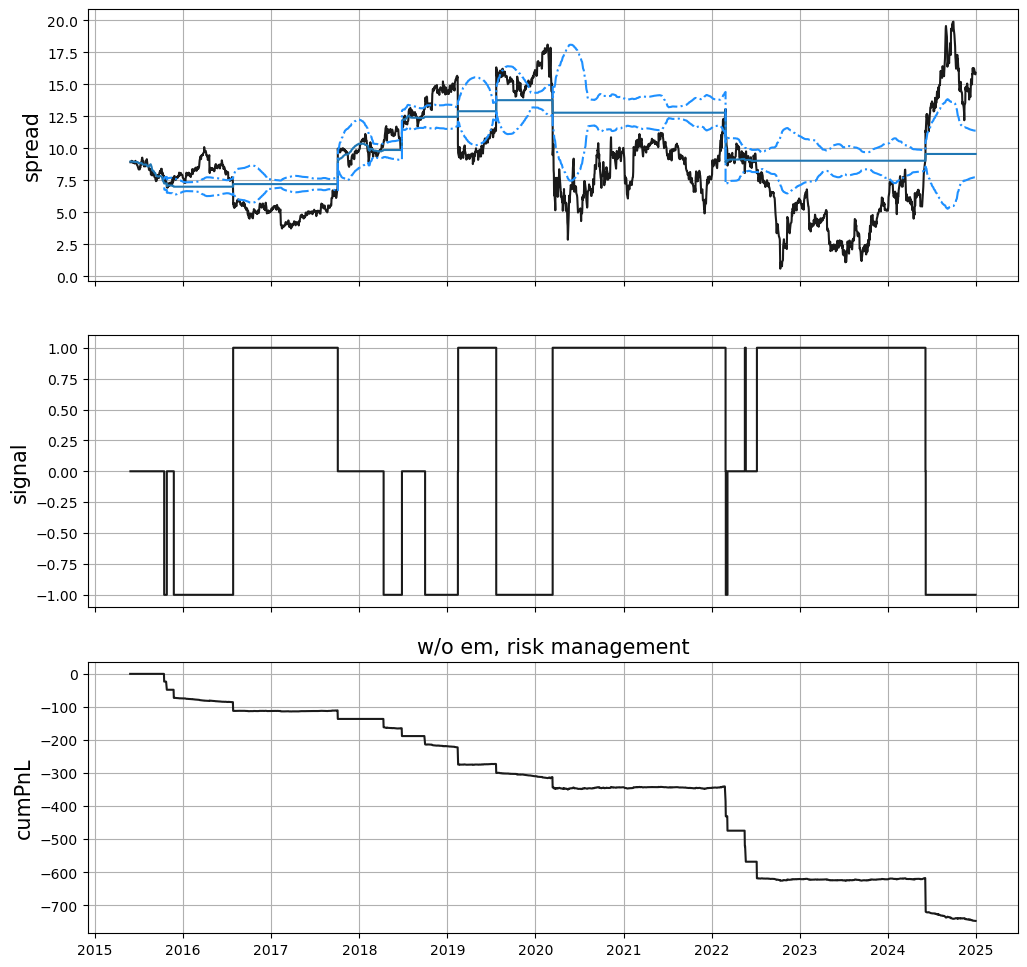

In [24]:
df_kf_noem_r= data.copy()
rolling_window =100
mu,beta = kf(df_kf_noem_r,['KO','PEP'],separation_time=datetime(2026,1,1),em=False)
mu=mu[rolling_window-1:]
beta = beta[rolling_window-1:]

df_kf_noem_r,mu,U,L = pair_trading_rolling(mu,beta,df_kf_noem_r,['KO','PEP'],
                          width=1,rolling_window=rolling_window,T_holding= None,
                                 stop_level= None,plot=True)
plt.title(r'w/o em, risk management',fontsize=15)

### Rebalancing pair trading
In this part, we change the trade spread weight in time, i.e following $\beta_t$ strictly rather than fix when having a position.
#### Daily return
The daily return is computed by
   $$
       R_d(t) = \frac{ sig(t-1) \big(p_1(t)-\beta_{t-1}p_2(t)  -S(t-1) \big)  }{  S(t-1)}
   $$
   Ignoring the case that $S(t-1)=0$ (set NA).

***Functions***

```pair_trading_rolling_rb```: Compute the spread, signal, cumlative PnL, etc from the    
 input $\mu$, $\beta$ and price data. Here we don't fix  $\mu$ and $\beta$ when holding the position. 

In [7]:
def pair_trading_rolling_rb(mu,beta,df,pair: list,width=1,
                         a_trade=0.003,a_short=0.0003,T_holding= None,
                         stop_level=None, rolling_window = 10 ,plot = False):
    df = df.iloc[rolling_window-1:].copy()
    price_1 = df[pair[0]].values
    price_2 = df[pair[1]].values
    
    spread = price_1 - beta*price_2
    
    # QQ = spread.copy()  this is for checking , can be ignored
    
    std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
    U=width*std_roll
    L=-width*std_roll
    if stop_level!= None:
        U_loss = stop_level*std_roll
        L_loss = -stop_level*std_roll  
    
    signal = np.zeros_like(spread)
    change= np.zeros_like(spread)
    cash = np.zeros_like(spread)
    position_value =np.zeros_like(spread)
    cumPnL = np.zeros_like(spread)
    R_d = np.zeros_like(spread)
    #trading record
    entry={}
    exit={}
    flip={}
    #record the holding time
    t_holding= 0
    status = 'active'
    for t in range(1,len(spread)):

        # if stop loss limitation is triggered
        if status == 'loss_stop':
            signal[t]=0
            if (spread[t]>mu[t] + L[t]) and (spread[t]<mu[t] + U[t]):
                status = 'active'

        if status =='active':
            # none at t-1
            if  signal[t-1] ==0:
                if  spread[t] <mu[t] + L[t]:
                    signal[t]= 1
                    t_holding=1

                elif spread[t]>mu[t] +U[t]:
                    signal[t]=-1
                    t_holding=1

                else:
                    signal[t] =0
                    
            # has position at t-1
            else:
                # holding time limitation
                if T_holding != None:
                    if t_holding > T_holding:
                        status = 'holding_stop'
                        # current traded spread using beta at entry time
                        signal[t] = 0
                        t_holding = 0

                #spread deviaion limit, higher priority
                if stop_level != None:
                    #long spread but it drops too low
                    case1 = (signal[t-1]==1 and spread[t] <= mu[t] + L_loss[t])
                    # short spread but it rises to high
                    case2 = (signal[t-1]==-1 and spread[t] >= mu[t] + U_loss[t])
                    if case1 or case2:
                        
                        status = 'loss_stop'
                        signal[t]= 0 
                        t_holding = 0
                        
                # if limitatioion still isn't triggered        
                if status =='active':
                    # long at t-1
                    if  signal[t-1] ==1:

                        if  spread[t] < mu[t]:
                            signal[t]= 1
                            t_holding+=1

                        elif spread[t]>mu[t]+U[t]:
                            signal[t]=-1
                            t_holding=1

                        else:
                            signal[t] =0
                            t_holding=0

                    # short at t-1
                    else:
                        if  spread[t] > mu[t]: 
                            signal[t]= -1
                            t_holding+=1

                        elif spread[t]< mu[t]+L[t]:
                            signal[t]=1
                            t_holding=1

                        else:
                            signal[t] =0
        
        if signal[t-1] != signal[t]:
            
            # record the profit when liquidation
            liquidation = signal[t-1]*(price_1[t] - beta[t-1]*price_2[t])

            #trading fee including liquidation + new position
            fee_trade = a_trade *( np.abs((signal[t]-signal[t-1])*price_1[t] )
                                +np.abs((signal[t]*beta[t]-signal[t-1]*beta[t-1])*price_2[t]) )
            
            position_value[t] = signal[t]*spread[t]
            change[t] = liquidation - position_value[t] - fee_trade
            
            
            date = pd.to_datetime(df.index[t])
            if signal[t]==0:
                exit[date]=spread[t]-mu[t]
            elif signal[t-1] ==0:
                entry[date]=spread[t]-mu[t]
            else:
                flip[date]=spread[t]-mu[t]
        #if no trade, update position value
        else:
            position_value[t] = signal[t]*spread[t]
            rebalance =  signal[t]*(beta[t] -beta[t-1])*price_2[t]
            fee_trade = a_trade *np.abs(rebalance) 
            change[t] = -rebalance - fee_trade

        
        # holding cost from short
        if signal[t] == -1:
            fee_short = a_short * price_1[t]
        elif signal[t]== 1:
            fee_short = a_short * beta[t]*price_2[t]
        else:
            fee_short = 0
        change[t] -= fee_short
        #cash and PnL update
        cash[t] = cash[t-1]  + change[t] 
        cumPnL[t] =  cash[t] + position_value[t]
        R_d[t] =   (price_1[t]- price_1[t-1]-beta[t-1]*(price_2[t]-price_2[t-1]))/spread[t-1]
        
        # if holding time limitation is on, reactivate at the end of each period
        if  status == 'holding_stop':
            status = 'active'
        

        

    df.loc[:,'spread'] = spread
    df.loc[:,'signal'] = signal
    df.loc[:,'change'] = change
    df.loc[:,'cash'] = cash
    df.loc[:,'cumPnL']= cumPnL
    df.loc[:,'position_value']=position_value
    df.loc[:,'R_d'] = R_d
    if plot:
        fig,ax = plt.subplots(4,1,sharex=True,figsize=(12,20))
        ax[0].plot(df.index,spread-mu,c='k',label='spread',alpha=0.8)
        ax[0].axhline(y=0)
        ax[0].plot(df.index,L,c='dodgerblue',ls='dashdot',label='threshold')
        ax[0].plot(df.index,U,c='dodgerblue',ls='dashdot')
        ax[0].scatter(entry.keys(),entry.values(),label='entry',marker='*',c='orange',s=80)
        ax[0].scatter(exit.keys(),exit.values(),label='exit',marker='*',c='red',s=80)
        ax[0].scatter(flip.keys(),flip.values(),label='flip',marker='*',c='green',s=80)
        ax[0].legend()
        ax[0].set_ylabel('spread- mu',fontsize=15)

        ax[1].plot(df.index,signal,c='k')
        ax[1].set_ylabel('signal ',fontsize=15)

        ax[2].plot(df.index,cumPnL,c='k') 
        ax[2].set_ylabel('cumPnL',fontsize=15)
        
        ax[3].plot(df.index,df['R_d'], c='k')
        ax[3].set_ylabel('Daily return',fontsize=15)
        for i in range(4):
            ax[i].grid()
        plt.show()
    return df,mu,U,L


Text(0.5, 1.0, 'w/o em, risk management')

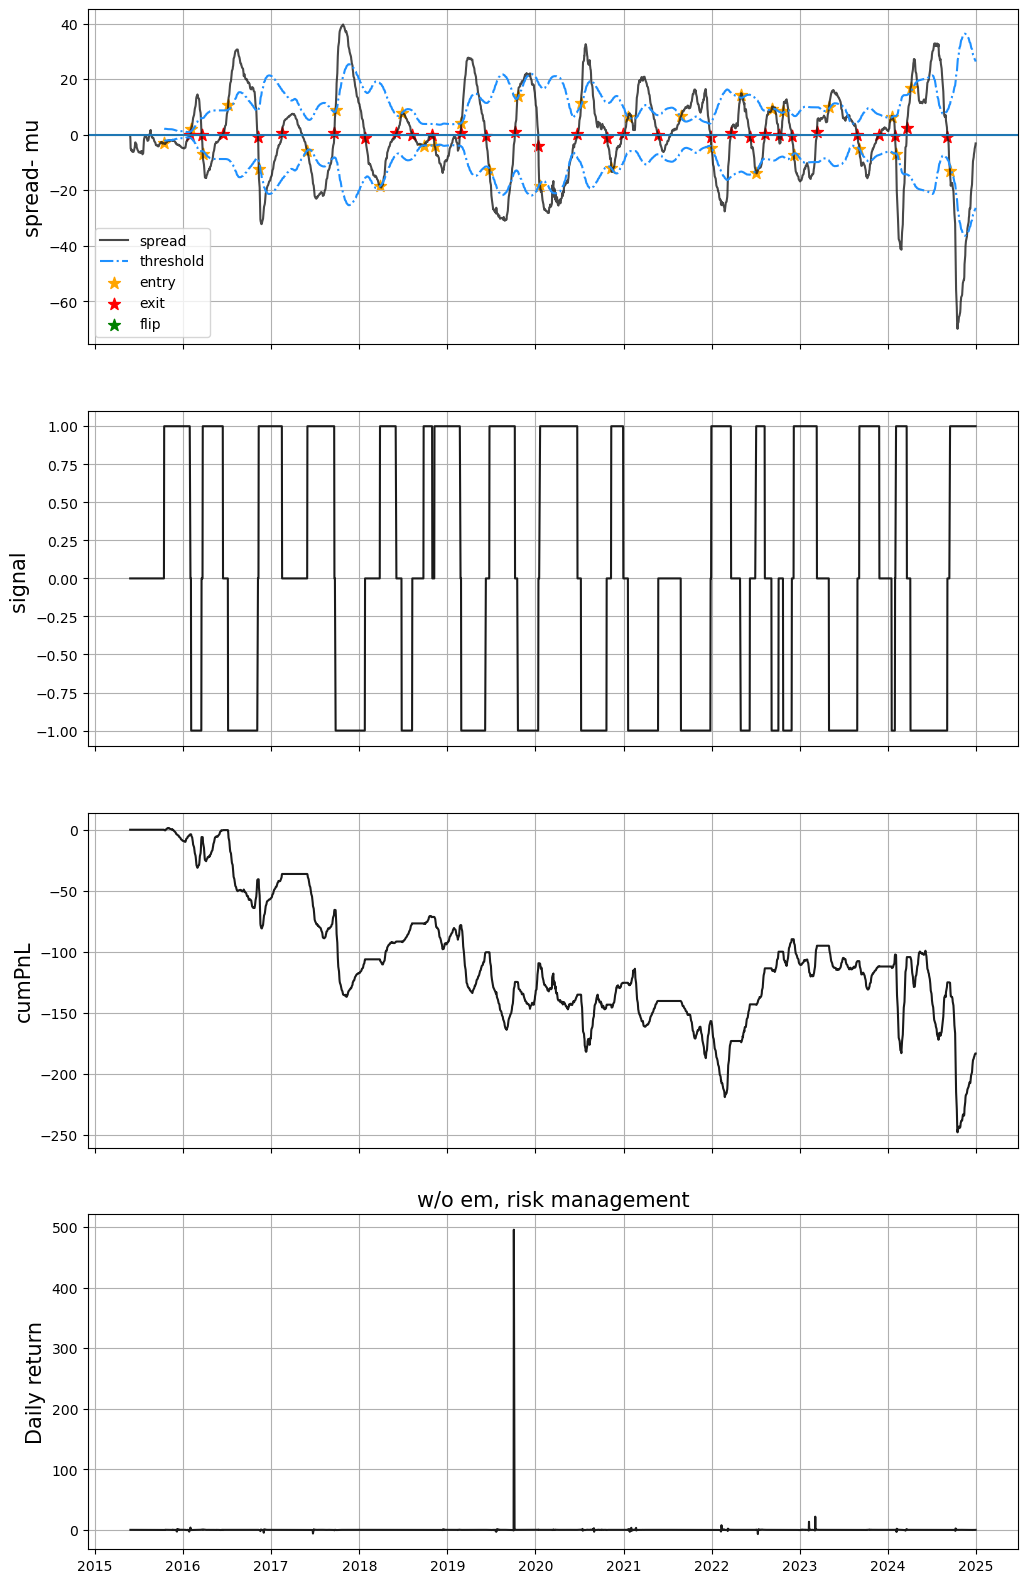

In [32]:
df_lsrb = data.copy()
rolling_window = 100
beta ,mu = ls_rolling(df_lsrb,['KO','PEP'],rolling_window =rolling_window )
df_lsrb,mu,U,L = pair_trading_rolling_rb(mu,beta,df_lsrb,pair=['KO','PEP'],width=1,
                                    T_holding=None,rolling_window = rolling_window
                                    ,stop_level=None,plot=True)
plt.title(r'w/o em, risk management',fontsize=15)

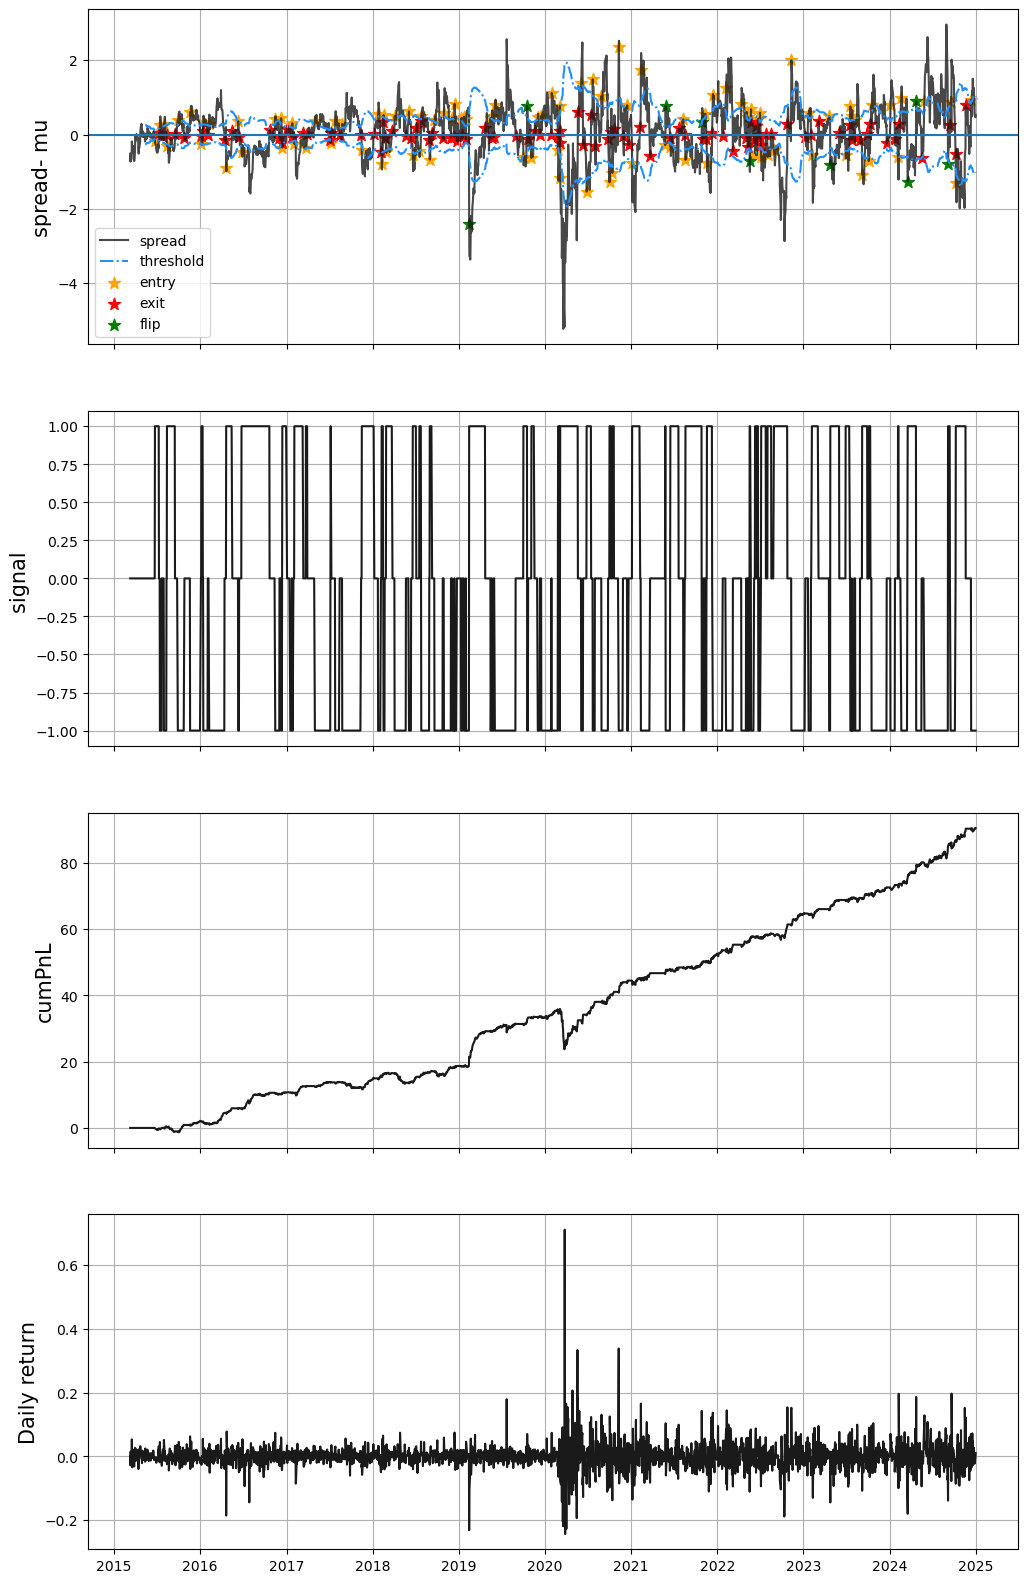

In [45]:
df_kf_noem_rb= data.copy()
rolling_window =46
mu,beta = kf(df_kf_noem_rb,['KO','PEP'],separation_time=datetime(2026,1,1),em=False)
mu=mu[rolling_window-1:]
beta = beta[rolling_window-1:]

df_kf_noem_rb,mu,U,L = pair_trading_rolling_rb(mu,beta,df_kf_noem_rb,['KO','PEP'],
                          width=1,rolling_window=rolling_window,T_holding= None,
                                 stop_level= None,plot=True)
# plt.title(r'w/o em, risk management',fontsize=15)

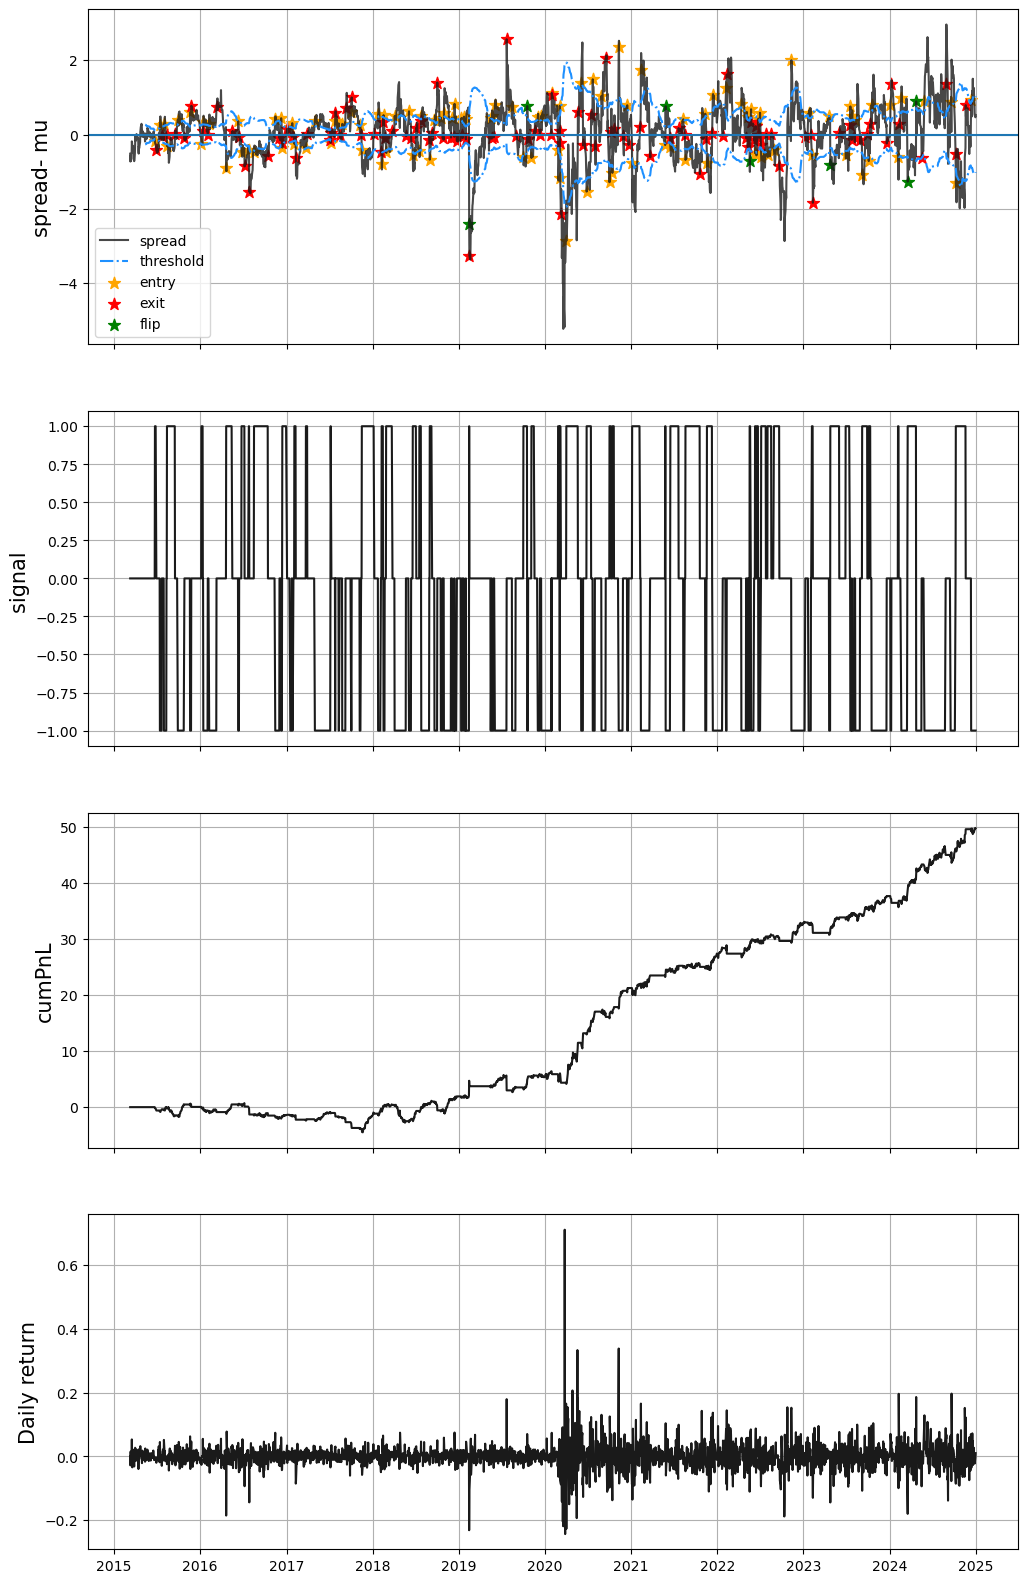

In [43]:
df_kf_noem_rb= data.copy()
rolling_window =46
mu,beta = kf(df_kf_noem_rb,['KO','PEP'],separation_time=datetime(2026,1,1),em=False)
mu=mu[rolling_window-1:]
beta = beta[rolling_window-1:]

df_kf_noem_rb,mu,U,L = pair_trading_rolling_rb(mu,beta,df_kf_noem_rb,['KO','PEP'],
                          width=1,rolling_window=rolling_window,T_holding= None,
                                 stop_level= 3,plot=True)
# plt.title(r'w/o em, stop loss level=3',fontsize=15)

### Statistics

#### mean-reversion return versus position value
We want to estimate the each mean-reversion return, which is the profit 
of liquiditating a spread position devided by the initial position and rebalance cost( can be computed by cash change): 
$$
   \frac{[\tilde{S}(t_{exit}) - \big(\tilde{S}(t_{entry}) +  Cash(t_{exit}) -  Cash(t_{entry} \big) ]}{ \lvert \tilde{S}(t_{entry}) +  Cash(t_{exit}) -  Cash(t_{entry})  \rvert}
$$
where $\tilde{S}(t) = sig(t) \cdot S(t)$.

In [8]:
def R_reversion(dff,separation_time=datetime(2023,1,1)):
    df = dff[dff.index>separation_time].copy()
    df['diff'] = df['signal'].diff()
    df= df[df['diff']!=0].copy() 
    signal = df['signal'].values
    cash = df['cash'].values
    spread = df['spread'].values
    R =[]
    # for out sample, entry may before sep time, so we just set zero 
    t_entry = 0
    for t in range(1,len(df)):
        #enter position
        if signal[t-1] == 0:
            t_entry = t
        # exit previous position
        else:
            t_exit = t
            cost = signal[t_entry]*spread[t_entry]+ cash[t_exit] - cash[t_entry]
            R.append( (signal[t_entry]*spread[t_exit] - cost)/np.abs(cost)  )
            
            # signal flip,exit then enter
            if signal[t] !=0:
                t_entry = t
    return R

In [ ]:
R_r_os=R_reversion(df_kf_noem_rb)
R_r_whole=R_reversion(df_kf_noem_rb,separation_time=df_kf_noem_rb.index[0])

plt.hist(R_r_os,bins=100 ,density=True,label = 'os')
plt.hist(R_r_whole,bins=100,density=True,alpha=0.45,label='whole')
plt.grid()
plt.legend()
plt.show()

#### Metrics

In [46]:
# df=df_kf_noem_rb.copy()
df = df_kf_noem_rb[df_kf_noem_rb.index>datetime(2023,1,1)].copy()
R_d_whole =df_kf_noem_rb['R_d'].iloc[1:].copy()
R_d_os =df['R_d'].iloc[1:].copy()

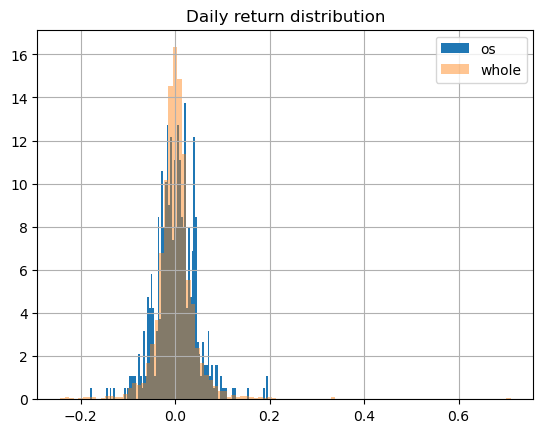

In [49]:
plt.hist(R_d_os,bins=100 ,density=True,label = 'os')
plt.hist(R_d_whole,bins=100,density=True,alpha=0.45,label='whole')
plt.grid()
plt.legend()
plt.title('Daily return distribution')
plt.show()

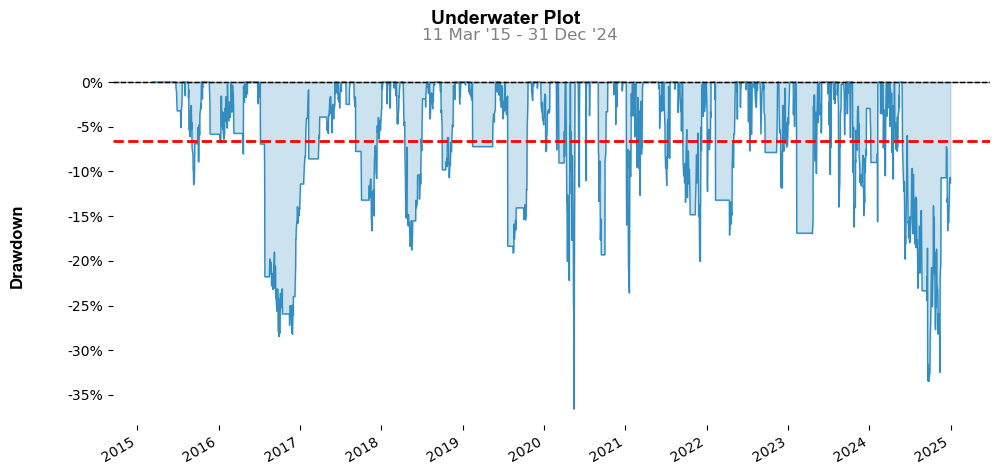

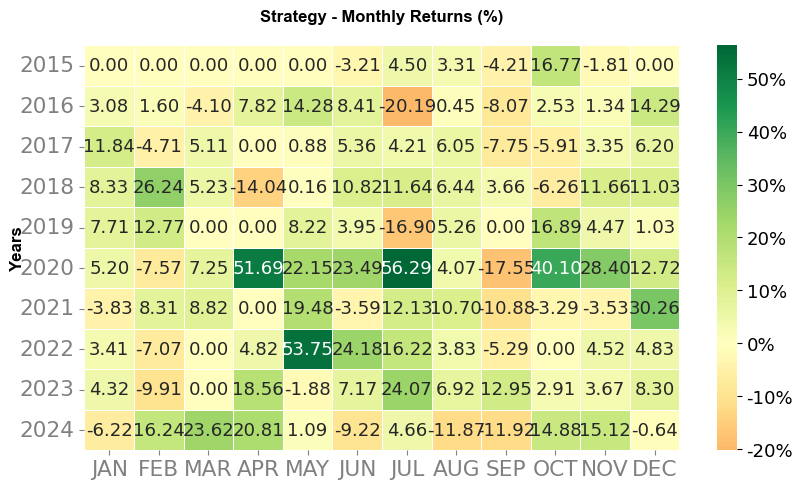

In [472]:
qs.plots.drawdown(R_d_whole)
qs.plots.monthly_heatmap(R_d_whole)


The maximum drawdown happens at 2020/3 which corresponds to COVID19 market crash.

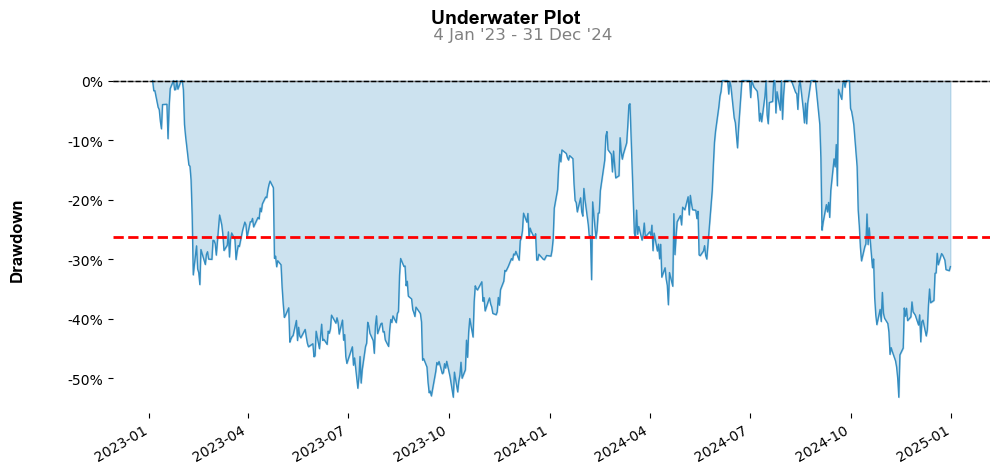

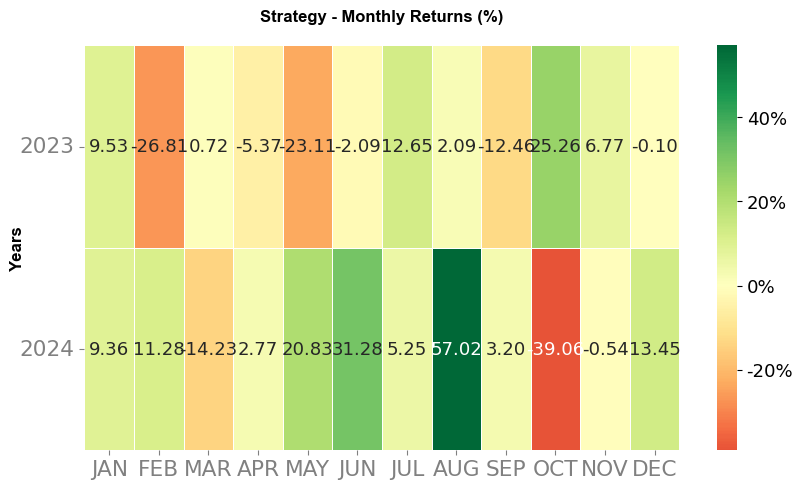

In [50]:
qs.plots.drawdown(R_d_os)
qs.plots.monthly_heatmap(R_d_os)


#### Tables

In [53]:
R_r_whole = pd.DataFrame({'R_r':R_r_whole})
R_r_os = pd.DataFrame({'R_r':R_r_os})

stats_dict = { 'whole':[qs.stats.avg_return(R_d_whole),
qs.stats.volatility(R_d_whole),qs.stats.skew(R_d_whole),
qs.stats.var(R_d_whole,sigma=1.28),qs.stats.cvar(R_d_whole,sigma=1.28),qs.stats.sharpe(R_d_whole,rf=0.03),
qs.stats.max_drawdown(R_d_whole) ,R_r_whole['R_r'].mean(),len(R_r_whole[R_r_whole['R_r']>0])/len(R_r_whole)],
 'out sample':[qs.stats.avg_return(R_d_os),qs.stats.volatility(R_d_os), 
qs.stats.skew(R_d_os),
qs.stats.var(R_d_os,sigma=1.28),qs.stats.cvar(R_d_os,sigma=1.28),
qs.stats.sharpe(R_d_os,rf=0.03), qs.stats.max_drawdown(R_d_os),
R_r_os['R_r'].mean(),len(R_r_os[R_r_os['R_r']>0])/len(R_r_os) ]
}

pd.DataFrame(stats_dict,index=['avg R_d','volatility'
                , 'skew','90 % var','90% cvar','Sharpe ratio,3% rf'
        ,'max drawdown','avg R_r','fraction of profitable R_r'])


,whole,out sample
avg R_d,0.000666,0.001822
volatility,0.667843,0.696475
skew,2.185403,0.295515
90 % var,-0.087909,-0.090550
90% cvar,-0.129728,-0.117598
"Sharpe ratio,3% rf",0.207121,0.616948
max drawdown,-0.863759,-0.531663
avg R_r,0.111459,0.097326
fraction of profitable R_r,0.598131,0.571429


#### Other parameters
Can risk management help in 2020 covid crash?

In [378]:
def metrics(data=data,stop_level=None,width=1,separation_time=datetime(2023,1,1),rolling_window=46):
    df= data.copy()
    mu,beta = kf(df,['KO','PEP'],separation_time=separation_time,em=False)
    mu=mu[rolling_window-1:]
    beta = beta[rolling_window-1:]

    df,mu,U,L = pair_trading_rolling_rb(mu,beta,df,['KO','PEP'],
                          width=width,rolling_window=rolling_window,T_holding= None,
                                 stop_level= stop_level,plot=False)
    
    R_whole =df['R_d'].copy()
    R_OS = df[df.index>separation_time]['R_d'].copy()
    _= { 'whole sharp':qs.stats.sharpe(R_whole,rf=0.03), 'out sample sharp':qs.stats.sharpe(R_OS,rf=0.03)
        , 'whole max drawdown':qs.stats.max_drawdown(R_whole), 'out sample max drawdown':  
        qs.stats.max_drawdown(R_OS)
    }
    return _

In [397]:
def plot_metrics_hm(data=data):    
    stop_lost = ['None']+ list(range(2,11))
    rws = np.arange(10,101)
    df_whole_s =pd.DataFrame(columns = stop_lost,index = rws) 
    df_whole_mdd =pd.DataFrame(columns = stop_lost,index = rws) 
    df_os_s =pd.DataFrame(columns = stop_lost,index = rws) 
    df_os_mdd =pd.DataFrame(columns = stop_lost,index = rws) 

    for stop in stop_lost:
        print(stop)
        for rw in rws:
            if stop =='None':
                _= metrics(data,stop_level=None, rolling_window=rw)
            else:
                _= metrics(data,stop_level=stop, rolling_window=rw)
            df_whole_s.loc[rw,stop] = _['whole sharp'] 
            df_whole_mdd.loc[rw,stop]=_['whole max drawdown'] 
            df_os_s.loc[rw,stop]=_['out sample sharp']
            df_os_mdd.loc[rw,stop]=_['out sample max drawdown']
    fig,ax = plt.subplots(2,2,figsize=(15,15) )
    df_list = [df_whole_s,df_whole_mdd,df_os_s, df_os_mdd ] 
    text = ['whole/SR','whole/MDD','os/SR','os/MDD']
    for i in range(4):
        i_1 = i%2
        i_2 = int(i/2)
        #unify cbar scale
        # sharpe ratio
        if i_1 ==0:
            s_min = min(df_whole_s.min().min(),df_os_s.min().min() )
            s_max = max(df_whole_s.max().max(),df_os_s.max().max() )
        #max drawdown
        else:
            s_min = min(df_whole_mdd.min().min(),df_os_mdd.min().min() )
            s_max = max(df_whole_mdd.max().max(),df_os_mdd.max().max() )
        sns.heatmap( df_list[i].apply(pd.to_numeric),ax=ax[i_1,i_2 ] ,vmin=s_min,vmax=s_max
                    ,cmap='coolwarm',cbar=True,
                 linewidth=0.01,linecolor='k')
        ax[i_1,i_2].set_title(text[i])
        if (i_1==0) &(i_2==0):
            ax[i_1,i_2].set_ylabel('rolling window')
            ax[i_1,i_2].set_xlabel('stop loss level')

None
2
3
4
5
6
7
8
9
10


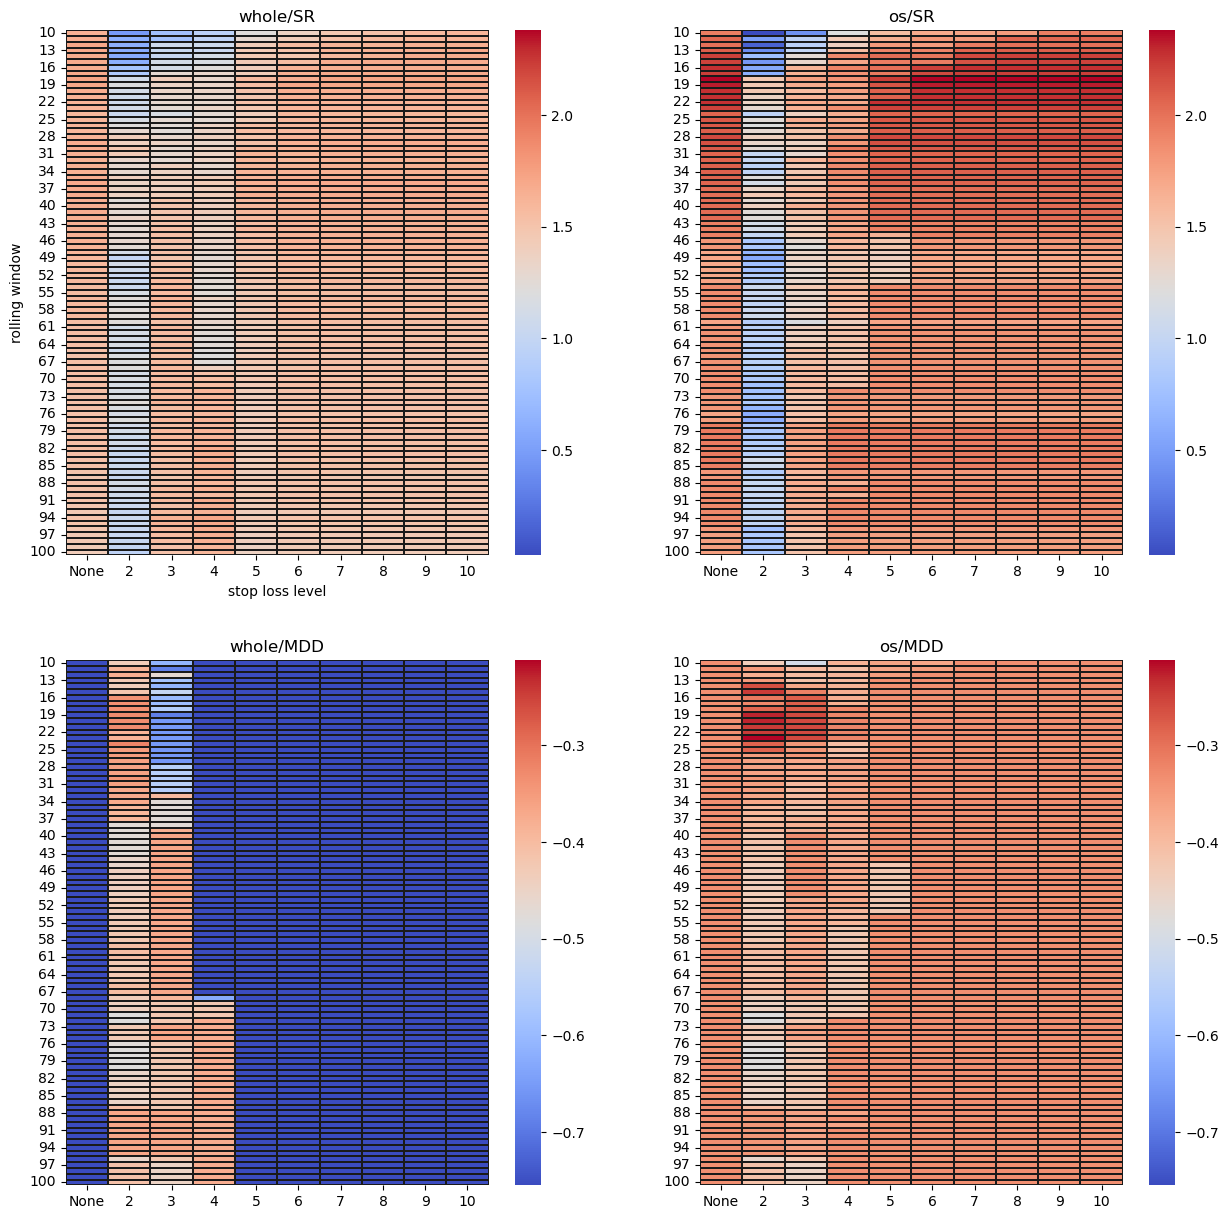

In [396]:
plot_metrics_hm()



Some  conclusions:
* whole timeframe Sharpe ratio <= out sample in most case due to COVID crash

* whole timeframe maximum drawdown> out sample in some subsets(e.g stop loss level >=4 or None ), which may due to COVID crash. 


* Proper stop loss settings( 2\~4) indeed mitigate the maximun drawdown from crash, but not only whole/os sharpe ratios lower, out sample maximun drawdown gets worse(except at roll 16\~25). 

* High stop loss levels seem to have no effect, i.e almost same as none.

* Best whole/os parameters stop loss: none\~2 ,  roll: 16\~25

#### Waiting time
Some statics about holding time of a spread position and waiting time to a new spread position.

In [277]:
def waiting(dff,unit = 'd'):
    df = dff.copy()
    df['diff'] = df['signal'].diff()
    df= df[df['diff']!=0].copy() 
    # start from the first signal that is zero(since sometimes df is truncated)
    t_ini = df[df['signal']==0].index[0] 
    df=df.loc[t_ini:].copy()
    signal = df['signal'].values
    waiting_exit=[]
    waiting_entry = []
    #default initial exit time setting
    t_exit =0
    for t in range(1,len(df)):
        #enter position
        if signal[t-1] == 0:
            t_entry = t
            dT_entry= df.index[t_entry] - df.index[t_exit]
            if unit =='d':
                waiting_entry.append( (dT_entry).days  )
            elif unit =='h':
                waiting_entry.append( (dT_entry).total_seconds() / 3600  )
            elif unit =='s':
                waiting_entry.append( (dT_entry).total_seconds()   )
        # exit previous position
        else:
            t_exit = t
            dT_exit= df.index[t_exit] - df.index[t_entry]
            if unit =='d':
                waiting_exit.append( (dT_exit).days  )
            elif unit =='h':
                waiting_exit.append( (dT_exit).total_seconds() / 3600  )
            elif unit =='s':
                waiting_exit.append( (dT_exit).total_seconds()   )

            # signal flip,exit then enter
            if signal[t] !=0:
                t_entry = t
    return waiting_entry,waiting_exit

In [401]:
T = waiting(df_kf_noem_rb)

In [ ]:
bins=np.unique(T)
Poi = np.array( [stats.expon.pdf(n ,loc=0.9988950797957159,scale=1) for n in range(1,200)])


In [ ]:
import statsmodels
statsmodels.graphics.gofplots.qqplot(np.array(T), dist=stats.expon, line='s')


In [1361]:
np.mean(T)

23.149532710280372

Text(0.5, 1.0, 'rebalancing Kalman w/o risk management')

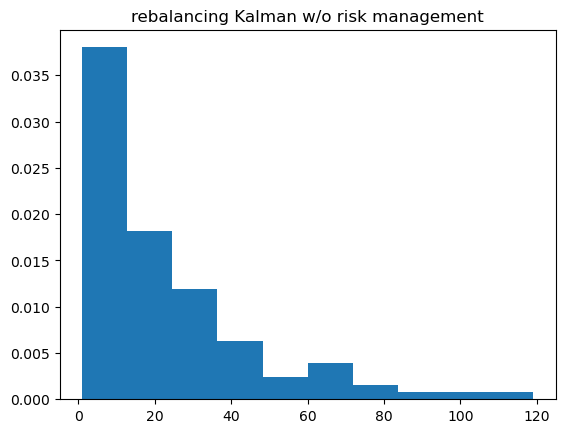

In [1339]:
plt.hist(T,bins=10,density=True);
plt.title('rebalancing Kalman w/o risk management')

### Filtering and constructing portfolio of pairs
Now we want to propose a method to filter out trading pairs from an asset univers.

Is it possibile to trade tradfin asset and crypto asset pair?

We dynamically assign weight w.r.t performance(momentum or market cap ETF) 

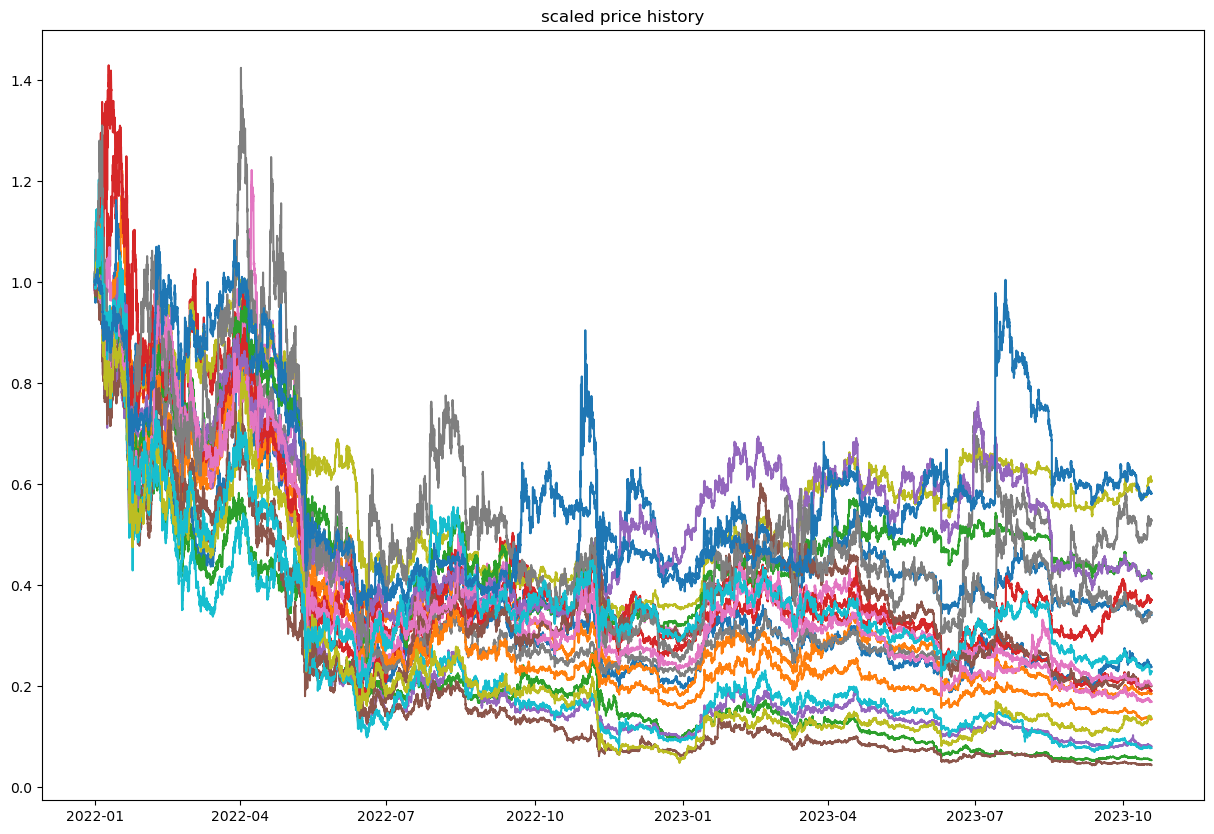

In [394]:
plt.figure(figsize=(15,10))
for s in df_all.columns:
    plt.plot(df_all.index,df_all[s]/df_all[s].iloc[0])
plt.title('scaled price history')
plt.show()

#### Some preparation

In [54]:
df_all = pd.read_csv("C:/Users/std92/OneDrive/文件/AMM/other's notes and codes/token_style/Data/all_assets.csv",index_col='datetime')
df_all.index= df_all.index.astype('str')
df_all.index=df_all.index.str.replace(r'[+-]\d{2}:\d{2}$', '', regex=True)
df_all.index = pd.to_datetime(df_all.index)

C:\Users\std92\AppData\Local\Temp\ipykernel_19600\1889517594.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("C:/Users/std92/OneDrive/文件/AMM/other's notes and codes/token_style/Data/all_assets.csv",index_col='datetime')


In [55]:
df_all = df_all[df_all['label'].isin(['Binance','coinbase' ])  ]
df_all  =df_all[df_all.dT=='1H']
df_all=df_all.drop(columns=['dT','volume','type']).copy()

# keep ETH, BTC from Binance
df_all = df_all[ ~ ((df_all['label']=='coinbase'  )  & (df_all['token'].isin(['BTC & USD','ETH & USD'   ])  )              ) ] 

In [56]:
df = df_all.reset_index()
_=df.groupby(['label','token'])['datetime'].agg(['min','max'])

In [57]:
filtered_list=list(_[_['min']>datetime(2022,1,1)].index.get_level_values(1))

_=_[~_.index.get_level_values(1).isin(filtered_list)]

ini = _['min'].max()
fin = _['max'].min()


In [58]:
df_all = df[df['datetime'].between(ini,fin,inclusive='both')].set_index('datetime')
df_all = df_all[~df_all['token'].isin(filtered_list)]


In [59]:
df_all=df_all[['close','token']].pivot(columns='token')
df_all.columns=df_all.columns.get_level_values(1)

In [10]:
# df_all.to_csv('mean_reversion_tokens.csv')

df_all= pd.read_csv('mean_reversion_tokens.csv',index_col='datetime')
df_all.index = pd.to_datetime(df_all.index)

#### Filter


In [11]:
print(f'data start from {df_all.index[0]} to {df_all.index[-1]}')

data start from 2022-01-01 00:00:00 to 2023-10-18 16:00:00


In [422]:
def pair_filter(df,separation_time,coin_p_thereshold=0.05,adf_p_threshold=0.05):
    dff=df[df.index<=separation_time].copy()
    assets = dff.columns.values
    pair_lists =[]
    for (asset1,asset2) in combinations(assets,2 ):
        score, coin_p_value,_= coint(dff[asset1],dff[asset2])
        if coin_p_value <= coin_p_thereshold:
            # X = sm.add_constant(np.log(dff[asset2].values))
            # result = sm.OLS(np.log(dff[asset1].values),X).fit()
            X = sm.add_constant(dff[asset2].values)
            result = sm.OLS(dff[asset1].values,X).fit()
            b = result.params[1]
            spread = dff[asset1].values  - b * dff[asset2].values
            adf_p_value = adfuller(spread)[1]
        else:
            continue
        if adf_p_value <=adf_p_threshold:
            pair_lists.append([asset1,asset2])
        
    return pair_lists

In [423]:
pairs_list = pair_filter(df_all,datetime(2022,3,1))

#### Log price as spread
We impose the leverage-to-one condition on asset part, i.e the weight vector of a pair and cash after rebalance at time t is
$$
( \omega_1(t) , \omega_2(t) , \omega_{cash}(t) ) = ( sig(t)\cdot  \frac{1}{1+\beta_t}
, -sig(t) \cdot \frac{\beta}{1+\beta_t}, 1- sig(t) \cdot \frac{1-\beta_t}{1+\beta_t} )
$$

At time t-1:

$W(t-1)$: total wealth at time t-1


$\big( \color{lime}{\omega_1(t-1)} \color{white}{,}
\color{orange}{\omega_2(t-1)} \color{white}\big) = 
sig(t-1) \cdot
\big( \color{lime}{\frac{1}{1+\beta(t-1)}}  \color{white}{,} 
\color{orange}{\frac{-\beta(t-1)}{1+\beta(t-1)}} \color{white}{\big)}$: weights of assets at t-1

                     ↓( time t, price change)
 
* asset 1: $p_1(t-1) \to p_1(t)$ => $\color{lime}{R_1(t)}$ 
* asset 2: $p_2(t-1) \to p_2(t)$ => $\color{orange}{R_2(t)}$
* Return before subtractin fee : $R'(t) \equiv \sum_{i=1}^2 \omega_i(t-1) R_i(t) $

Corresponding  total wealth at time t, before rebalance:

 $$ 
 \color{cyan}W'(t) \color{white} =
\bigl( 1+ R'(t)  \bigr)
 \cdot \color{green} W(t-1)
$$
Here we assume $1+ R'(t) >0$(or $W'(t)>0$), otherwisw we just stop the strategy. 
New weights due to price change,before rebalance(prime superscription):
$$
\color{lime}\omega'_1(t) \color{white}=  
\frac{ \color{lime} \omega_1(t-1)  (1+ R_1(t) )  \color{white}}{
\bigl( 1+  R'(t)  \bigr)
} 
$$

$$ 
\color{orange} \omega'_2(t) \color{white}
= \frac{ \color{orange} \omega_2(t-1)  (1+ R_2(t)) \color{white} }{
\bigl( 1+  R'(t)  \bigr)
} 
$$

$$
\omega'_{cash}(t) = 
\frac{\omega_{cash}(t-1)}{
\bigl( 1+  R'(t)  \bigr)
}
$$



                     ↓(rebalance, including trade and short fee)
 
We want to rebalance the portifolio so that the weights after paying the  fee is $( \omega_1(t) , \omega_2(t) , \omega_{cash}(t) )$.
The fee is assumed to be propotional to the volume(trading) or position size(shorting). If we want to get a precise value of fee, we need to solve system of equations. Here since the fee are usually much smaller, we can instead approximate them by the following:

* trading fee
$$
\color{red}{\alpha_{trade}}  \; \color{cyan} W'_t   \color{white}
{\sum_{i=1}^2 (\lvert 
  \color{cyan}\omega'_i(t) \color{white}- \color{green}
  \omega_i(t)\color{white}\rvert)}
= 
 \color{red}{\alpha_{trade}} \color{white} 
 \big(1+R'(t) \big)  \color{green} W_{t-1}\; \color{white}{\sum_{i=1}^2 \lvert 
  \color{cyan}\omega'_i(t) \color{white}- \color{green}
  \omega_i(t)\color{white}\rvert}
  $$

* shorting fee
$$
  \color{red}\alpha_{short} \color{white} \sum_{i=1}^2 W_{t-1}\max(
  -\color{green}\omega_i(t-1) \color{white},0) 
$$

We denote their sum as $f_t$. Then

* Wealth after rebalance at time t:

$$ 
\begin{align*}
\color{green}W_t \color{white}
& = \color{cyan}W'_t  \color{white}- \color{red}f_t \color{white}
\\
&=  \bigl\{ \big(1+R'(t) \big) \big( 1- \color{red}{\alpha_{trade}}  \; \color{white}{\sum_{i=1}^2 \lvert 
  \color{cyan}\omega'_i(t) \color{white}- \color{green}
  \omega_i(t)\color{white}\rvert}  \big) 
\\  
& - \color{red}\alpha_{short} \color{white} \sum_{i=1}^2 \max(
  -\color{green}\omega_i(t-1) \color{white},0)  \bigr\}  \color{green}W_{t-1}
\end{align*}
$$
So the exact amount of asset at time t after rebalance is 
$$ ( \color{green}W_t \color{white} \cdot \color{lime}\omega_1(t)\color{white} , 
\color{green}W_t \color{white}\cdot \color{orange}\omega_2(t) \color{white}, 
\color{green}W_t \color{white}\cdot \omega_{cash}(t) ) $$

* Retrun at time t:

$$ 
\begin{align*}
R_t &= \frac{W_t - W_{t-1}}{W_{t-1}}
\\
&=  R'(t)  -\big(1+R'(t) \big) \big(\color{red}{\alpha_{trade}}  \; \color{white}{\sum_{i=1}^2 \lvert 
  \color{cyan}\omega'_i(t) \color{white}- \color{green}
  \omega_i(t)\color{white}\rvert}  \big) 
\\  
& - \color{red}\alpha_{short} \color{white} \sum_{i=1}^2 \max(
  -\color{green}\omega_i(t-1) \color{white},0)  
\end{align*}
$$



In [27]:
def pair_trading_rolling_rb2(df,spread,b,mu,std_roll,a_trade,a_short,width):
    p_1 = np.log(df.iloc[:,0].values)
    p_2 = np.log(df.iloc[:,1].values)
    U=width*std_roll
    L=-width*std_roll
    signal = np.zeros_like(spread)
    wealth = np.ones_like(spread)
    b_1 = 1/(1+b)
    b_2 = -b/(1+b)
    for t in range(1,len(spread)):

            # none at t-1
            if  signal[t-1] ==0:
                if  spread[t] <mu[t] + L[t]:
                    signal[t]= 1

                elif spread[t]>mu[t] +U[t]:
                    signal[t]=-1

                else:
                    signal[t] =0
                    
            # has position at t-1
            elif  signal[t-1] ==1:
                if  spread[t] < mu[t]:
                    signal[t]= 1
                elif spread[t]>mu[t]+U[t]:
                    signal[t]=-1
                else:
                    signal[t] =0
            # short at t-1
            else:
                if  spread[t] > mu[t]: 
                    signal[t]= -1

                elif spread[t]< mu[t]+L[t]:
                    signal[t]=1

                else:
                    signal[t] =0

            #assets return        
            R_1 = p_1[t] - p_1[t-1]
            R_2 = p_2[t] - p_2[t-1]
            R_unreb = signal[t-1]*b_1[t-1]*R_1 + signal[t-1]*b_2[t-1]*R_2
            # new assets weights before reb 
            w_1_unreb =  ((1+R_1)*signal[t-1]*b_1[t-1])/(1+R_unreb)
            w_2_unreb =  ((1+R_2)*signal[t-1]*b_2[t-1])/(1+R_unreb)
            
            # W'_t
            wealth_unreb = (1+R_unreb)* wealth[t-1]
            if wealth_unreb< 0 :
                print('bankrupt' )
                break
            #fee
            fee_trade = a_trade *wealth_unreb*( np.abs(w_1_unreb - signal[t]*b_1[t])
                                            + np.abs(w_2_unreb - signal[t]*b_2[t]))
            fee_short = a_short*wealth[t-1]*(max(-signal[t-1]*b_1[t-1],-signal[t-1]*b_2[t-1]))
            # W_t
            wealth[t] = wealth_unreb - fee_trade - fee_short

    return wealth


bankrupt
bankrupt
bankrupt


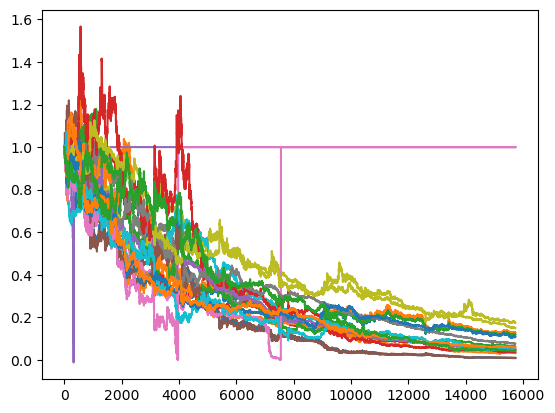

In [31]:

for pair in pairs_list:
    # pair= pairs_list[0]
    separation_time= datetime(2022,3,1)
    kf_parameters(df_all,pair,separation_time)
    
    mu,b = kf(df_all,pair,separation_time=separation_time,em=False)
    
    p_1 = np.log(df_all[pair[0]].values)
    p_2 = np.log(df_all[pair[1]].values)
    spread = 1/(1+b) *p_1 - b/(1+b) * p_2
    std_roll = pd.Series(spread - mu).rolling(window=10 ).std().values
    _=pair_trading_rolling_rb2(df_all[pair],spread,b,mu,std_roll,
                               a_trade=0.003,a_short=0.0003,width=1)
    plt.plot(_)
plt.show()

#### Price as spread

In [365]:
def pair_trading_rolling_rb2(mu,beta,df,pair: list,width=1,
                         a_trade=0.003,a_short=0.0003, rolling_window = 10 ):
    price_1 = df[pair[0]].values
    price_2 = df[pair[1]].values
    
    spread = price_1 - beta*price_2
    
    # QQ = spread.copy()  this is for checking , can be ignored
    
    std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
    U=width*std_roll
    L=-width*std_roll
    signal = np.zeros_like(spread)
    change= np.zeros_like(spread)
    cash = np.zeros_like(spread)
    position_value =np.zeros_like(spread)
    cumPnL = np.ones_like(spread)
    R_d = np.zeros_like(spread)

    #record the holding time
    t_holding= 0
    for t in range(1,len(spread)):

        # none at t-1
        if  signal[t-1] ==0:
            if  spread[t] <mu[t] + L[t]:
                signal[t]= 1
                t_holding=1

            elif spread[t]>mu[t] +U[t]:
                signal[t]=-1
                t_holding=1

            else:
                signal[t] =0
                
        # has position at t-1
        else:
            # long at t-1
            if  signal[t-1] ==1:

                if  spread[t] < mu[t]:
                    signal[t]= 1
                    t_holding+=1

                elif spread[t]>mu[t]+U[t]:
                    signal[t]=-1
                    t_holding=1

                else:
                    signal[t] =0
                    t_holding=0

            # short at t-1
            else:
                if  spread[t] > mu[t]: 
                    signal[t]= -1
                    t_holding+=1

                elif spread[t]< mu[t]+L[t]:
                    signal[t]=1
                    t_holding=1

                else:
                    signal[t] =0
    
        if signal[t-1] != signal[t]:
            # record the profit when liquidation
            liquidation = signal[t-1]*(price_1[t] - beta[t-1]*price_2[t])

            #trading fee including liquidation + new position
            fee_trade = a_trade *( np.abs((signal[t]-signal[t-1])*price_1[t] )
                                +np.abs((signal[t]*beta[t]-signal[t-1]*beta[t-1])*price_2[t]) )
            
            position_value[t] = signal[t]*spread[t]
            change[t] = liquidation - position_value[t] - fee_trade

        #if no trade, update position value
        else:
            position_value[t] = signal[t]*spread[t]
            rebalance =  signal[t]*(beta[t] -beta[t-1])*price_2[t]
            fee_trade = a_trade *np.abs(rebalance) 
            change[t] = -rebalance - fee_trade

        
        # holding cost from short
        if signal[t] == -1:
            fee_short = a_short * price_1[t]
        elif signal[t]== 1:
            fee_short = a_short * beta[t]*price_2[t]
        else:
            fee_short = 0
        change[t] -= fee_short
        #cash and PnL update
        cash[t] = cash[t-1]  + change[t] 
        cumPnL[t] =  cash[t] + position_value[t]
        R_d[t] =   (price_1[t]- price_1[t-1]-beta[t-1]*(price_2[t]-price_2[t-1]))/spread[t-1]

        dff = df[pair].copy()
        dff.loc[:,'signal'] = signal
        dff.loc[:,'spread'] = spread
        dff.loc[:,'std']  = std_roll
        dff.loc[:,'U']  = U
        dff.loc[:,'L']  = L
        dff.loc[:,'mu'] = mu
    return cumPnL, dff


In [ ]:
# average waiting time berfore 2022/3/1
avg_T_exit =[]
avg_T_entry =[]

for i,pair in enumerate(pairs_list):
    print(i)
    separation_time= datetime(2022,3,1)
    rolling_window = 10
    kf_parameters(df_all,pair,separation_time)
    df = df_all[df_all.index<=separation_time].iloc[rolling_window-1:].copy()
    
    mu,b = kf(df,pair,separation_time=separation_time,em=False)
    
    p_1 = df[pair[0]].values
    p_2 = df[pair[1]].values
    spread = p_1 - b * p_2
    std_roll = pd.Series(spread - mu).rolling(window=10 ).std().values
    _=pair_trading_rolling_rb2(mu,b,df,pair,width=1,
                         a_trade=0.003,a_short=0.0003, rolling_window=rolling_window)
    entry,exit = waiting(_[1], unit='h' )
    avg_T_exit.append( np.mean(exit) )
    avg_T_entry.append(np.mean(entry))

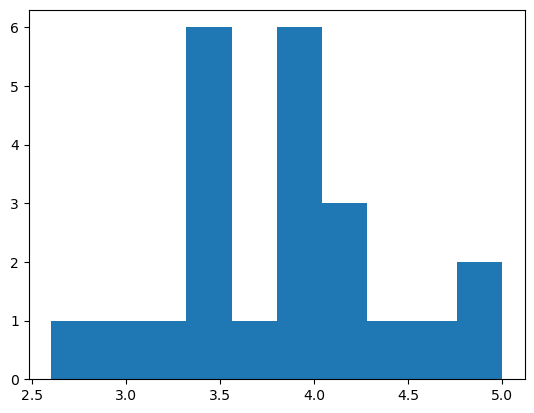

In [279]:
# average entry wating time on training set(before separation)
plt.hist(avg_T_entry)
plt.show()

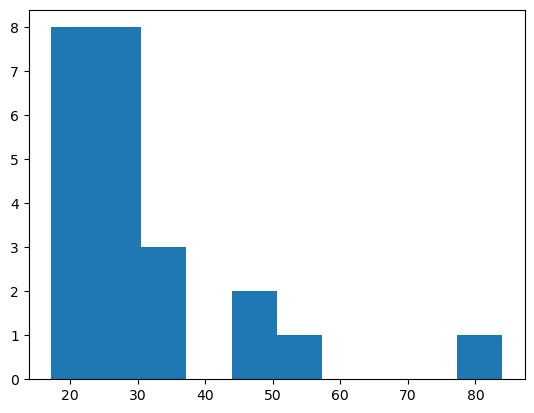

In [280]:
# average entry wating time on training set(before separation)
plt.hist(avg_T_exit)
plt.show()

In [283]:
print(f'average entry wating time of all pairs(training set) is {np.mean(avg_T_entry)} hrs' )
print(f'average exit wating time of all pairs(training set) is {np.mean(avg_T_exit)} hrs' )

average entry wating time of all pairs(training set) is 3.8347139233124876 hrs
average exit wating time of all pairs(training set) is 30.75984322400815 hrs


#### Pairs Weights assign
Now we want to limit the number  of traded pairs(default is 5) and assign capital weight. The update period is ```n_update``` * ```rolling_window```(default is 5*10, at least one cycle for most pairs in training period)

In [16]:
#This is for log price spread
def kf_parameters(dff,pair:list,separation_time):
    df=dff[dff.index<=separation_time].copy()
    b=ls(df,pair,separation_time,log=True)
    spread_ls=1/(1+b)*df[pair[0]].apply(np.log) - b/(1+b)*df[pair[1]].apply(np.log) 
    mu = np.mean(spread_ls  )
    std = np.std( spread_ls  -mu  )
    std_2 = df[pair[1]].apply(np.log).std()
    global ini_mean,inicov,alpha,tran_cov,obs_cov
    ini_mean=(b, mu ) 
    inicov=1e1
    ini_cov=inicov * np.eye(2)
    alpha=10**-5
    tran_cov=np.array([ [alpha*std/std_2,0],
                        [ alpha*std,0]     ])
    obs_cov=std 

In [49]:
# this is for price as spread
def kf_parameters(dff,pair:list,separation_time):
    df=dff[dff.index<=separation_time].copy()
    b=ls(df,pair,separation_time,log=True)
    spread_ls=1*df[pair[0]] - b*df[pair[1]] 
    mu = np.mean(spread_ls  )
    std = np.std( spread_ls  -mu  )
    std_2 = df[pair[1]].std()
    global ini_mean,inicov,alpha,tran_cov,obs_cov
    ini_mean=(b, mu ) 
    inicov=1e1
    ini_cov=inicov * np.eye(2)
    alpha=10**-5
    tran_cov=np.array([ [alpha*std/std_2,0],
                        [ alpha*std,0]     ])
    obs_cov=std 

In [230]:
#This is for log price spread
def PnL_filter(df_all,separation_time,pairs:list,rolling_window=10,max_pairs=5,
               width=1,a_trade=0.003,a_short=0.0003,n_update=5):
    df_all = df_all.iloc[rolling_window-1:].copy()
    wealth_dict ={}
    for pair in pairs:
        print(pair)
        kf_parameters(df_all,pair,separation_time)

        mu,b = kf(df_all,pair,separation_time=separation_time,em=False)

        p_1 = np.log(df_all[pair[0]].values)
        p_2 = np.log(df_all[pair[1]].values)
        spread = 1/(1+b) *p_1 - b/(1+b) * p_2
        std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
        pair_name = pair[0].replace(' & USD',' & ')+pair[1].replace(' & USD','')
        wealth_dict[pair_name]= pair_trading_rolling_rb2(df_all[pair],
                                spread,b,mu,std_roll,a_trade,a_short,width)
    
    names = list(wealth_dict.keys())
    wealth_arrays = np.array([wealth_dict[k] for k in names])  
    R_array = wealth_arrays[:,1:]/wealth_arrays[:,:-1] -1
    top_pairs_each_step = []
    df = pd.DataFrame( columns=['R',1,2,3,4,5]    ,index=df_all.index)
    df=df.iloc[n_update*rolling_window:].copy()
    values_at_t = wealth_arrays[:, n_update*rolling_window]
    top_idx = np.argsort(-values_at_t)[:max_pairs]
    
    top_values = values_at_t[top_idx]
    top_pairs = [names[i] for i in top_idx]
    # if wealth<0, remove from choices
    top_values  =np.where(top_values<0,0,top_values)
    top_pairs = np.where(top_values<0,'None',top_pairs)
    
    weight = np.array([v/top_values.sum() for  v in top_values ] )
    for t in range(n_update*rolling_window+1, len(df)):
        df.loc[df.index[t],'R'] = weight@R_array[top_idx,t] 
        df.loc[df.index[t], [1,2,3,4,5]] = top_pairs
        
        #update pairs choices
        if t % (n_update*rolling_window):
            # ignore fee from liquidate previous choosen pairs, if there are 
            
            values_at_t = wealth_arrays[:, t]
            
            top_idx = np.argsort(-values_at_t)[:max_pairs]
            top_values = values_at_t[top_idx]
            top_pairs = [names[i] for i in top_idx]
            # if wealth<0, remove from choices
            top_values  =np.where(top_values<0,0,top_values)
            top_pairs = np.where(top_values<0,'None',top_pairs)
            
            weight = np.array([v/top_values.sum() for  v in top_values ] )
    return df

In [316]:
#This is for  price spread
def PnL_filter(df_all,separation_time,pairs:list,rolling_window=10,max_pairs=4,
               width=1,a_trade=0.003,a_short=0.0003,n_update=5):
    df_all = df_all.iloc[rolling_window-1:].copy()
    wealth_dict ={}
    for pair in pairs:
        print(pair)
        kf_parameters(df_all,pair,separation_time)

        mu,b = kf(df_all,pair,separation_time=separation_time,em=False)

        p_1 = df_all[pair[0]].values
        p_2 = df_all[pair[1]].values
        spread = p_1 - b * p_2
        std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
        pair_name = pair[0].replace(' & USD',' & ')+pair[1].replace(' & USD','')
        wealth_dict[pair_name],_= pair_trading_rolling_rb2(mu,b,df_all,pair,width,a_trade,
                                                     a_short, rolling_window)
    
    names = list(wealth_dict.keys())
    wealth_arrays = np.array([wealth_dict[k] for k in names])  
    R_array = wealth_arrays[:,1:]/wealth_arrays[:,:-1] -1
    top_pairs_each_step = []
    df = pd.DataFrame( columns=['R']+list(range(1,max_pairs+1))    ,index=df_all.index)
    df=df.iloc[n_update*rolling_window:].copy()
    values_at_t = wealth_arrays[:, n_update*rolling_window]
    top_idx = np.argsort(-values_at_t)[:max_pairs]
    
    top_values = values_at_t[top_idx]
    top_pairs = [names[i] for i in top_idx]
    # if wealth<0, remove from choices
    top_values  =np.where(top_values<0,0,top_values)
    top_pairs = np.where(top_values<0,'None',top_pairs)
    df.loc[df.index[n_update*rolling_window], list(range(1,max_pairs+1)) ] = top_pairs

    weight = np.array([v/top_values.sum() for  v in top_values ] )
    for t in range(n_update*rolling_window+1, len(df)):
        df.loc[df.index[t],'R'] = weight@R_array[top_idx,t] 
        df.loc[df.index[t], list(range(1,max_pairs+1)) ] = top_pairs
        
        #update pairs choices
        if t % (n_update*rolling_window):
            # ignore fee from liquidate previous choosen pairs, if there are 
            
            values_at_t = wealth_arrays[:, t]
            
            top_idx = np.argsort(-values_at_t)[:max_pairs]
            top_values = values_at_t[top_idx]
            top_pairs = [names[i] for i in top_idx]
            # if wealth<0, remove from choices
            top_values  =np.where(top_values<0,0,top_values)
            top_pairs = np.where(top_values<0,'None',top_pairs)
            
            weight = np.array([v/top_values.sum() for  v in top_values ] )
    return df

In [312]:
# testing the code

# rolling_window=10
# max_pairs=4
# width=1
# a_trade=0.003
# a_short=0.0003
# n_update=7
# df = df_all.iloc[rolling_window-1:].copy()
# wealth_dict ={}
# for pair in pairs_list:
#     print(pair)
#     kf_parameters(df,pair,separation_time)

#     mu,b = kf(df,pair,separation_time=separation_time,em=False)

#     p_1 = df[pair[0]].values
#     p_2 = df[pair[1]].values
#     spread = p_1 - b * p_2
#     std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
#     pair_name = pair[0].replace(' & USD',' & ')+pair[1].replace(' & USD','')
#     wealth_dict[pair_name]= pair_trading_rolling_rb2(mu,b,df,pair,width,a_trade,
#                                                      a_short, rolling_window)
names = list(wealth_dict.keys())
wealth_arrays = np.array([wealth_dict[k] for k in names])  
R_array = wealth_arrays[:,1:]/wealth_arrays[:,:-1] -1

top_pairs_each_step = []
df = pd.DataFrame( columns=['R']+list(range(1,max_pairs+1))    ,index=df.index)
df=df.iloc[n_update*rolling_window:].copy()
values_at_t = wealth_arrays[:, n_update*rolling_window]
top_idx = np.argsort(-values_at_t)[:max_pairs]

top_values = values_at_t[top_idx]
top_pairs = [names[i] for i in top_idx]
# if wealth<0, remove from choices
top_values  =np.where(top_values<0,0,top_values)
top_pairs = np.where(top_values<0,'None',top_pairs)
df.loc[df.index[n_update*rolling_window], list(range(1,max_pairs+1)) ] = top_pairs

weight = np.array([v/top_values.sum() for  v in top_values ] )
for t in range(n_update*rolling_window+1, len(df)):
    df.loc[df.index[t],'R'] = weight@R_array[top_idx,t] 
    df.loc[df.index[t], list(range(1,max_pairs+1)) ] = top_pairs
    
    #update pairs choices
    if t % (n_update*rolling_window):
        # ignore fee from liquidate previous choosen pairs, if there are 
        
        values_at_t = wealth_arrays[:, t]
        
        top_idx = np.argsort(-values_at_t)[:max_pairs]
        top_values = values_at_t[top_idx]
        top_pairs = [names[i] for i in top_idx]
        # if wealth<0, remove from choices
        top_values  =np.where(top_values<0,0,top_values)
        top_pairs = np.where(top_values<0,'None',top_pairs)
        
        weight = np.array([v/top_values.sum() for  v in top_values ] )


In [ ]:
df = PnL_filter(df_all,separation_time=datetime(2022,3,1),pairs=pairs_list)
df=df.fillna(0)


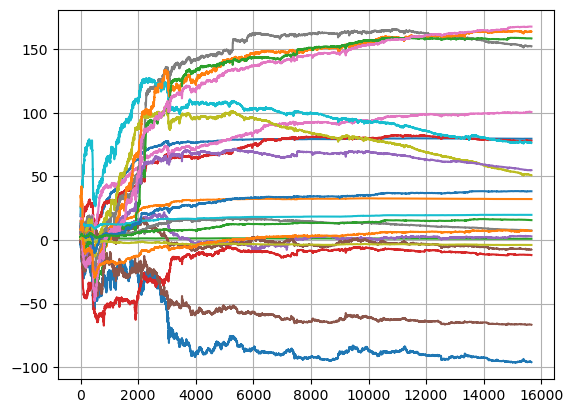

In [452]:
for w in wealth_arrays:
    plt.plot(w[n_update*rolling_window:])
    plt.grid()

plt.show()

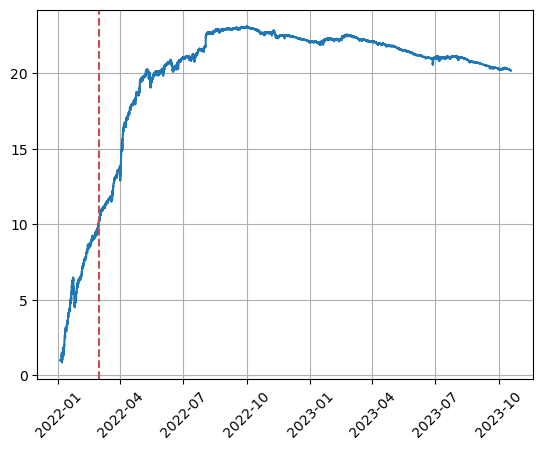

In [451]:
plt.plot((1 + df['R']).cumprod())
plt.xticks(rotation=45);
plt.axvline(x = datetime(2022,3,1) , c= 'r', ls ='--')
plt.grid()
plt.show()

In [431]:
# Try to find why strategy perform bad after 2023/4
top4_list =[['CRV & USD' , 'SOL & USD' ], ['AAVE & USD', 'SOL & USD'],['AAVE & USD' , 'LINK & USD'],['AVAX & USD' , 'DOT & USD']  ]

df_check = df_all.iloc[rolling_window-1:].copy()
df_list=[]
for i,pair in enumerate(top4_list):
    print(pair)
    kf_parameters(df_check,pair,separation_time)

    mu,b = kf(df_check,pair,separation_time=separation_time,em=False)

    p_1 = df_check[pair[0]].values
    p_2 = df_check[pair[1]].values
    spread = p_1 - b * p_2
    std_roll = pd.Series(spread - mu).rolling(window=rolling_window ).std().values
    _,dff= pair_trading_rolling_rb2(mu,b,df_check,pair)
    df_list.append(dff)


['CRV & USD', 'SOL & USD']
['AAVE & USD', 'SOL & USD']
['AAVE & USD', 'LINK & USD']
['AVAX & USD', 'DOT & USD']


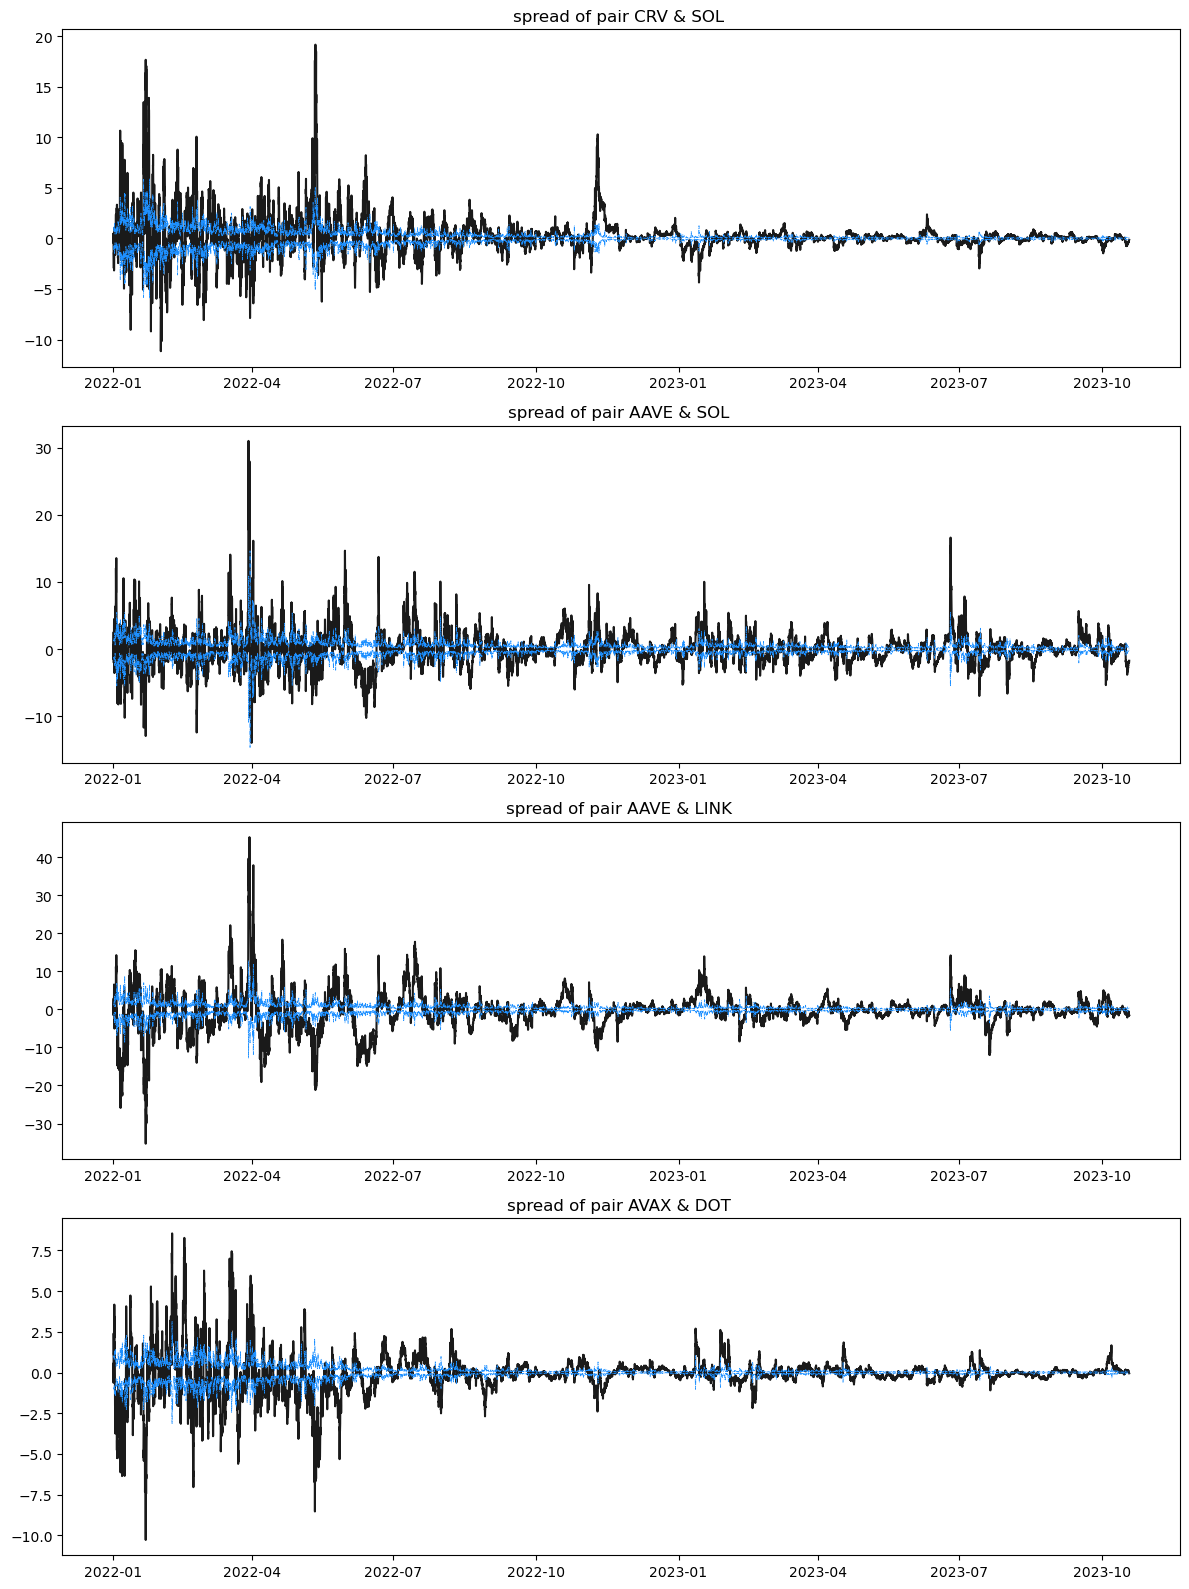

In [445]:
fig,ax = plt.subplots(4,1,figsize=(12,16))
for i,dff in enumerate(df_list):
    title = top4_list[i][0].replace('USD','')+top4_list[i][1].replace(' & USD','')

    # ax[i].plot(dff.index,(dff['spread'] - dff['mu'])/dff['std'],c='k')
    # ax[i].axhline(y=1,c='dodgerblue',ls='dashdot')
    # ax[i].axhline(y=-1,c='dodgerblue',ls='dashdot' )
    ax[i].plot(dff.index,(dff['spread'] - dff['mu']),c='k')
    ax[i].plot(dff.index,(dff['U']),c='dodgerblue',ls='dashdot',lw=0.5)
    ax[i].plot(dff.index,(dff['L']),c='dodgerblue',ls='dashdot',lw=0.5)

    ax[i].set_title(f'spread of pair {title} ')
plt.tight_layout()
plt.show()    

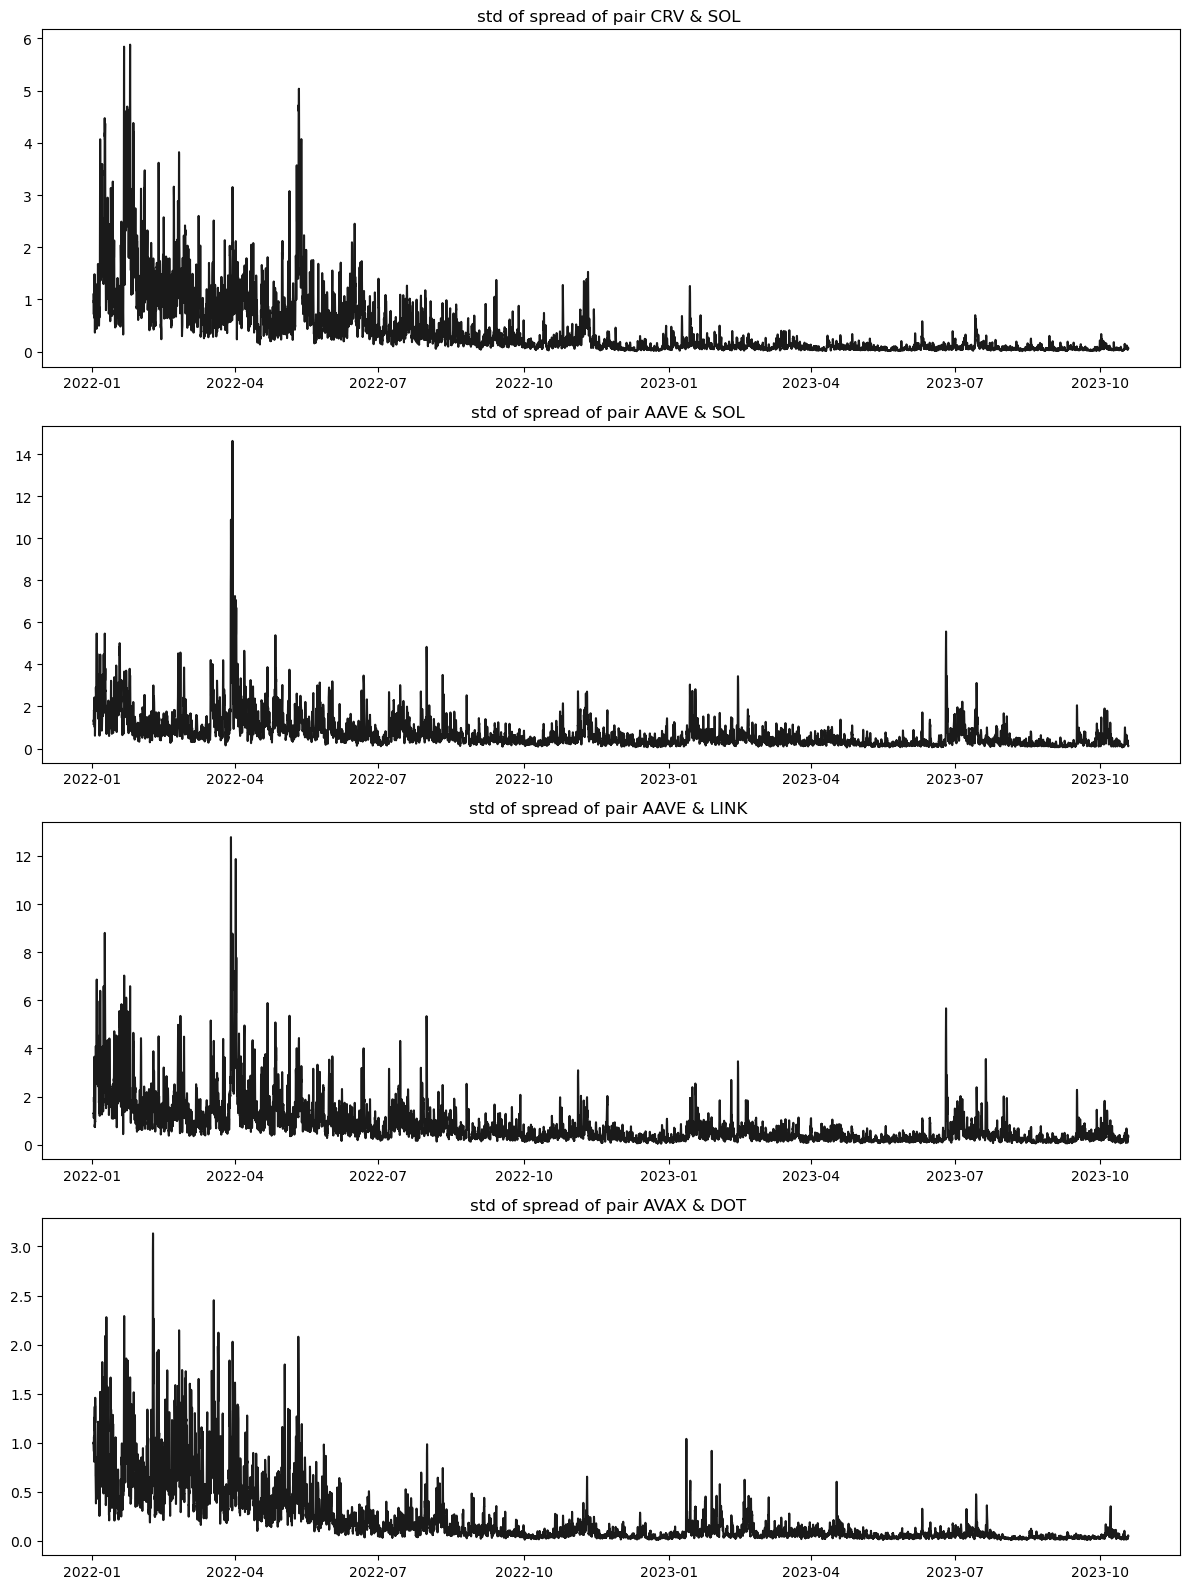

In [454]:
fig,ax = plt.subplots(4,1,figsize=(12,16))
for i,dff in enumerate(df_list):
    title = top4_list[i][0].replace('USD','')+top4_list[i][1].replace(' & USD','')

    # ax[i].plot(dff.index,(dff['spread'] - dff['mu'])/dff['std'],c='k')
    # ax[i].axhline(y=1,c='dodgerblue',ls='dashdot')
    # ax[i].axhline(y=-1,c='dodgerblue',ls='dashdot' )
    ax[i].plot(dff.index,(dff['std']),c='k')

    ax[i].set_title(f'std of spread of pair {title} ')
plt.tight_layout()
plt.show()    

In [437]:
a = []
for p in top4_list:
    a.append(p[0])
    a.append(p[1])
a= np.unique(a)

a = df_all[a].copy()
b= pd.DataFrame()
b['before2022/10']=a[a.index<datetime(2022,10,1)].std()
b['after 2022/10']=a[a.index>=datetime(2022,10,1)].std()
b

,before2022/10,after 2022/10
AAVE & USD,50.811757,10.447330
AVAX & USD,30.093115,3.190791
CRV & USD,1.183231,0.206351
DOT & USD,6.469478,0.863719
LINK & USD,5.378365,0.702236
SOL & USD,37.693282,5.214113


#### Metrics

In [449]:
R_is =df[df.index<=datetime(2022,3,1)]['R'] 

R_os = df[df.index>datetime(2022,3,1)]['R']


stats_dict = { 'in sample':[qs.stats.avg_return(R_is),
qs.stats.volatility(R_is),qs.stats.skew(R_is),
qs.stats.var(R_is,sigma=1.28),qs.stats.cvar(R_is,sigma=1.28),qs.stats.sharpe(R_is,rf=0.03),
qs.stats.max_drawdown(R_is)],
 'out sample':[qs.stats.avg_return(R_os),qs.stats.volatility(R_os), 
qs.stats.skew(R_os),
qs.stats.var(R_os,sigma=1.28),qs.stats.cvar(R_os,sigma=1.28),
qs.stats.sharpe(R_os,rf=0.03,annualize=1512), qs.stats.max_drawdown(R_os)]
}

pd.DataFrame(stats_dict,index=['avg R','volatility'
                , 'skew','90 % var','90% cvar','Sharpe ratio,3% rf'
        ,'max drawdown'])


,in sample,out sample
avg R,0.002039,0.000048
volatility,0.338624,0.022624
skew,-0.080208,-1.802860
90 % var,-0.042964,-0.002953
90% cvar,-0.104895,-0.005501
"Sharpe ratio,3% rf",1.362150,-0.771622
max drawdown,-0.419429,-0.126491


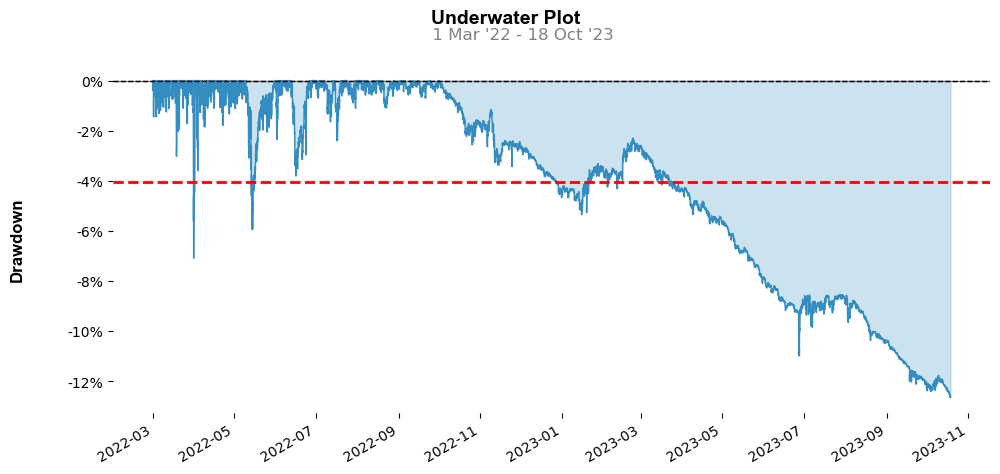

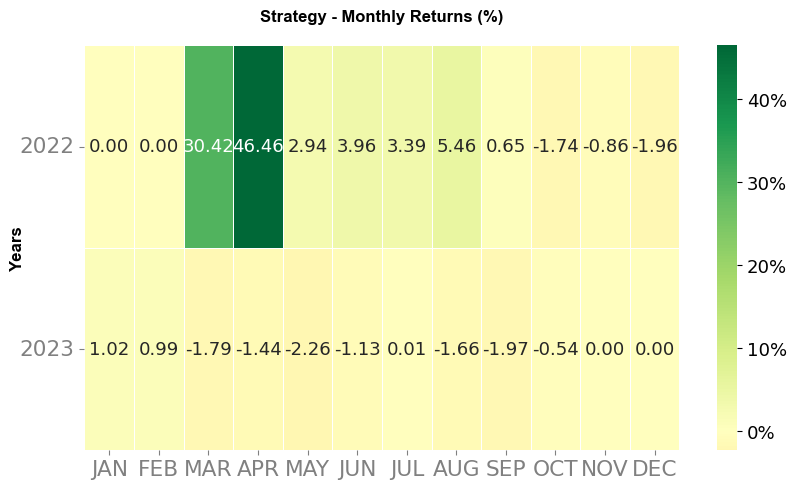

In [450]:
qs.plots.drawdown(R_os)
qs.plots.monthly_heatmap(R_os)

## Statistical arbitrage

[ref](https://bookdown.org/palomar/portfoliooptimizationbook/15.7-statarb.html)

Now we consider more than two assets into our mean-reversion portifolio. 



### VECM
Let $\{ p_i(t) \}_{t \geq 0}$ be the history prices of i-th asset and suppose that
all timeseries are $I(1)$. 

### Todo


* more analysis, statics, e.g waiting time

* multiple pairs weight assign

* generalize stat arb

* backtest method such as synthetic data